In [37]:
# DeepDisProt - Attention-based deep learning model to predict
# amino-acid specific states of disorderness for intrinsically-disordered proteins (IDP's)
# Author: Martin Shen Wang
# Date: 2026-03-21
# Use: CHEM4420 Project
'''
References to some of the layers used
- "Eric Nguyen et al. ,Sequence modeling and design from molecular to genome scale with 
   Evo.Science386,eado9336(2024).DOI:10.1126/science.ado9336"

- "Su J, Ahmed M, Lu Y, et al. Roformer: Enhanced transformer with rotary position 
   embedding[J]. Neurocomputing, 2024, 568: 127063."

- "Nie Z, Liu X, Chen J, et al. A unified evolution-driven deep learning framework 
   for virus variation driver prediction. Nature Machine Intelligence. Published online 
   January 17, 2025. doi:https://doi.org/10.1038/s42256-024-00966-9"
'''

# load packages
import torch
from torch import nn
import math
from einops import rearrange
import numpy as np
import os
import sys
import json
import time
import matplotlib.pyplot as plt
import configparser
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from io import StringIO

# For system writing
last_status_len = 0

def write_status(msg):
    global last_status_len
    # clear previous line
    sys.stderr.write('\r' + ' ' * last_status_len + '\r')
    # write new message
    sys.stderr.write(msg)
    sys.stderr.flush()
    last_status_len = len(msg)

# %%
class ModelParams:
    @property
    def dilations(self):
        return self._dilations
    @property
    def d_model(self):
        return self._d_model
    
    @property
    def s_conv_kernel(self):
        return self._s_conv_kernel
    
    @property
    def l_conv_kernel(self):
        return self._l_conv_kernel
    
    @property
    def max_seq_length(self):
        return self._max_seq_length
    
    @property
    def emb_base(self):
        return self._emb_base
    
    @property
    def dtype(self):
        return self._dtype
    
    @property
    def d_ff(self):
        return self._d_ff
    
    @property
    def src_vocb_size(self):
        return self._src_vocb_size
    
    @property
    def tgt_vocb_size(self):
        return self._tgt_vocb_size
    
    @property
    def num_heads(self):
        return self._num_heads
    
    @property
    def order(self):
        return self._order
    
    @property
    def emb_dim(self):
        return self._emb_dim
    
    # new properties for original HyenaEncoder
    
    
    def __init__(self, 
                 src_vocb_size: int,
                 tgt_vocb_size: int,
                 d_model: int, 
                 num_heads: int,
                 max_seq_length: int,
                 s_conv_kernel: int = 3, 
                 l_conv_kernel: int = 21, 
                 emb_base: int = 10000, 
                 d_ff: int = 512,
                 dtype = torch.float,
                 order = int,
                 emb_dim = int,dilations: list = None):
        assert d_model % num_heads == 0 and d_model % 2 == 0 and num_heads % 2 == 0, 'd_model must be divisible by num_heads and both d_model and num_heads must be even.\n'
        self._src_vocb_size = src_vocb_size
        self._tgt_vocb_size = tgt_vocb_size
        self._d_model = d_model
        self._num_heads = num_heads
        self._s_conv_kernel = s_conv_kernel
        self._l_conv_kernel = l_conv_kernel
        self._max_seq_length = max_seq_length
        self._emb_base = emb_base
        self._dtype = dtype
        self._d_ff = d_ff
        self._order = order
        self._emb_dim = emb_dim
        self._dilations = dilations if dilations is not None else [1, 1, 1]
        
        # Mutable variables
        self.conv_kernel = s_conv_kernel

def get_params(config_path):
    config = configparser.ConfigParser()
    config.read(config_path)
    d_str = config.get('model_architecture', 'dilations', fallback='1,1,1')
    d_list = [int(d.strip()) for d in d_str.split(',')]
    params = ModelParams(
        dilations = d_list,
        src_vocb_size = config.getint('model_architecture', 'src_vocb_size'),
        tgt_vocb_size = config.getint('model_architecture', 'tgt_vocb_size'),
        d_model = config.getint('model_architecture', 'd_model'), 
        num_heads = config.getint('model_architecture', 'num_heads'),
        max_seq_length = config.getint('model_architecture', 'max_seq_length'),
        s_conv_kernel = config.getint('model_architecture', 's_conv_kernel'), 
        l_conv_kernel = config.getint('model_architecture', 'l_conv_kernel'), 
        emb_base = config.getint('model_architecture', 'emb_base'), 
        d_ff = config.getint('model_architecture', 'd_ff'),
        dtype = eval(config.get('model_architecture', 'dtype')),
        order = config.getint('model_architecture', 'order'),
        emb_dim = config.getint('model_architecture', 'emb_dim')
    )
    return params
        
# class and method definition
class Hyena(nn.Module):
    # Modified from UniversalTools to fix inaccuracies of orig script
    def __init__(self, params: ModelParams):
        super(Hyena, self).__init__()
    
        # input x should be sized as B x L x d
        # where B is Batch size
        # L is length of the input sequence
        # d is dimension of a token
        
        # channel mix layers, dense layer for each column
        self.W_q = nn.Linear(params.d_model, params.d_model) # Query transformation
        self.W_k = nn.Linear(params.d_model, params.d_model) # Key transformation
        self.W_v = nn.Linear(params.d_model, params.d_model) # Value transformation
    
        # short convolution
        self.conv_q = nn.Conv1d(params.d_model, params.d_model, params.s_conv_kernel, stride=1, padding=params.s_conv_kernel//2)
        self.conv_k = nn.Conv1d(params.d_model, params.d_model, params.s_conv_kernel, stride=1, padding=params.s_conv_kernel//2)
        self.conv_v = nn.Conv1d(params.d_model, params.d_model, params.s_conv_kernel, stride=1, padding=params.s_conv_kernel//2)
    
        # gate function
        self.glu = nn.GLU(-1)
        
        # long convolution
        self.conv_l = nn.Conv1d(params.d_model, params.d_model, params.l_conv_kernel, stride=1, padding=params.l_conv_kernel//2)
    
    def forward(self, x):
        """
        X should be sized as (B, L, d) or (L, d)
        
        x => Q, K, V
        result: V x \sigma(Q x \sigma(K))
        """
        # channel mix: (B, L, d) => (B, L, d)
        q = self.W_q(x)
        k = self.W_k(x)
        v = self.W_v(x)
    
        # sequnce mix: (B, L, d) => (B, d, L) => (B, d, L) => (B, L, d)
        cq = self.conv_q(q.transpose(-2,-1)).transpose(-2,-1)
        ck = self.conv_k(k.transpose(-2,-1)).transpose(-2,-1)
        cv = self.conv_v(v.transpose(-2,-1)).transpose(-2,-1)
    
        # stack gq and gk: (B, L, d) + (B, L, d) => (B, L, 2d)
        mix_qk = torch.cat([cq, ck], dim=-1)
        
        # gate Q, K: (B, L, 2d) => (B, L, d)
        g_qk = self.glu(mix_qk)
    
        # long distance convolution: (B, L, d) => (B, d, L) => (B, d, L) => (B, L, d)
        l_qk = self.conv_l(g_qk.transpose(-2,-1)).transpose(-2,-1)
    
        # stack gq and gk: (B, L, d) + (B, L, d) => (B, L, 2d)
        mix_qkv = torch.cat([cv,l_qk], dim=-1)
        
        # gate on mix_qkv: (B, L, 2d) => (B, L, d)
        
        # print("Hyena operation completed")
        
        return self.glu(mix_qkv)

# fixed with proper weight initialization
class SwiGLU(nn.Module):
    def __init__(self, input_dim, output_dim=None):
        super().__init__()
        d = input_dim // 2
        self.linear_v = nn.Linear(d, d)
        self.output_proj = nn.Linear(d, d if output_dim is None else output_dim)
        # Proper initialization
        nn.init.xavier_uniform_(self.linear_v.weight)
        nn.init.zeros_(self.linear_v.bias)
        nn.init.xavier_uniform_(self.output_proj.weight)
        nn.init.zeros_(self.output_proj.bias)

    def forward(self, x):
        x1, x2 = torch.chunk(x, 2, dim=-1)
        swish = x1 * torch.sigmoid(x1)
        out = swish * self.linear_v(x2)
        return self.output_proj(out)

class SwiGLUHyena(nn.Module):
    # Modified from UniversalTools to fix inaccuracies of orig script
    def __init__(self, params: ModelParams):
        super(SwiGLUHyena, self).__init__()
    
        # input x should be sized as B x L x d
        # where B is Batch size
        # L is length of the input sequence
        # d is dimension of a token
        
        # channel mix layers, dense layer for each column
        self.W_q = nn.Linear(params.d_model, params.d_model) # Query transformation
        self.W_k = nn.Linear(params.d_model, params.d_model) # Key transformation
        self.W_v = nn.Linear(params.d_model, params.d_model) # Value transformation
    
        # short convolution
        self.conv_q = nn.Conv1d(params.d_model, params.d_model, params.s_conv_kernel, stride=1, padding=params.s_conv_kernel//2)
        self.conv_k = nn.Conv1d(params.d_model, params.d_model, params.s_conv_kernel, stride=1, padding=params.s_conv_kernel//2)
        self.conv_v = nn.Conv1d(params.d_model, params.d_model, params.s_conv_kernel, stride=1, padding=params.s_conv_kernel//2)
    
        # gate function
        self.swiglu = SwiGLU(input_dim=2*params.d_model, output_dim=params.d_model)
        # self.glu = nn.GLU(-1)
        
        # long convolution
        self.conv_l = nn.Conv1d(params.d_model, params.d_model, params.l_conv_kernel, stride=1, padding=params.l_conv_kernel//2)
        # layernorm
        self.norm_qk = nn.LayerNorm(2 * params.d_model)
        self.norm_qkv = nn.LayerNorm(2 * params.d_model)
    
    def forward(self, x):
        """
        X should be sized as (B, L, d) or (L, d)
        
        x => Q, K, V
        result: V x \sigma(Q x \sigma(K))
        """
        # channel mix: (B, L, d) => (B, L, d)
        q = self.W_q(x)
        k = self.W_k(x)
        v = self.W_v(x)
    
        # sequnce mix: (B, L, d) => (B, d, L) => (B, d, L) => (B, L, d)
        cq = self.conv_q(q.transpose(-2,-1)).transpose(-2,-1)
        ck = self.conv_k(k.transpose(-2,-1)).transpose(-2,-1)
        cv = self.conv_v(v.transpose(-2,-1)).transpose(-2,-1)
    
        # stack gq and gk: (B, L, d) + (B, L, d) => (B, L, 2d)
        mix_qk = torch.cat([cq, ck], dim=-1)
        
        # gate Q, K: (B, L, 2d) => (B, L, d)
        mix_qk = self.norm_qk(mix_qk) # layernorm after
        g_qk = self.swiglu(mix_qk)
        # g_qk = self.glu(mix_qk)
    
        # long distance convolution: (B, L, d) => (B, d, L) => (B, d, L) => (B, L, d)
        l_qk = self.conv_l(g_qk.transpose(-2,-1)).transpose(-2,-1)
    
        # stack gq and gk: (B, L, d) + (B, L, d) => (B, L, 2d)
        mix_qkv = torch.cat([cv,l_qk], dim=-1)
        
        # gate on mix_qkv: (B, L, 2d) => (B, L, d)
        
        # print("Hyena operation completed")
        mix_qkv = self.norm_qkv(mix_qkv) # layernorm after (added)
        return self.swiglu(mix_qkv)

######################################################################################
# Hyena model from original publication
def fftconv(u, k, D):
    seqlen = u.shape[-1]
    fft_size = 2 * seqlen
    
    k_f = torch.fft.rfft(k, n=fft_size) / fft_size
    u_f = torch.fft.rfft(u.to(dtype=k.dtype), n=fft_size)
    
    if len(u.shape) > 3: k_f = k_f.unsqueeze(1)
    y = torch.fft.irfft(u_f * k_f, n=fft_size, norm='forward')[..., :seqlen]

    out = y + u * D.unsqueeze(-1)
    return out.to(dtype=u.dtype)


@torch.jit.script 
def mul_sum(q, y):
    return (q * y).sum(dim=1)

class OptimModule(nn.Module):
    """ Interface for Module that allows registering buffers/parameters with configurable optimizer hyperparameters """

    def register(self, name, tensor, lr=None, wd=0.0):
        """Register a tensor with a configurable learning rate and 0 weight decay"""

        if lr == 0.0:
            self.register_buffer(name, tensor)
        else:
            self.register_parameter(name, nn.Parameter(tensor))

            optim = {}
            if lr is not None: optim["lr"] = lr
            if wd is not None: optim["weight_decay"] = wd
            setattr(getattr(self, name), "_optim", optim)
            

class Sin(nn.Module):
    def __init__(self, dim, w=10, train_freq=True):
        super().__init__()
        self.freq = nn.Parameter(w * torch.ones(1, dim)) if train_freq else w * torch.ones(1, dim)

    def forward(self, x):
        return torch.sin(self.freq * x)
    
    
class PositionalEmbedding(OptimModule):
    def __init__(self, emb_dim: int, seq_len: int, lr_pos_emb: float=1e-5, **kwargs): 
        """Complex exponential positional embeddings for Hyena filters."""  
        super().__init__()
        
        self.seq_len = seq_len
        # The time embedding fed to the filteres is normalized so that t_f = 1
        t = torch.linspace(0, 1, self.seq_len)[None, :, None] # 1, L, 1
        
        if emb_dim > 1:
            bands = (emb_dim - 1) // 2            
        # To compute the right embeddings we use the "proper" linspace 
        t_rescaled = torch.linspace(0, seq_len - 1, seq_len)[None, :, None]
        w = 2 * math.pi * t_rescaled / seq_len # 1, L, 1 
        
        f = torch.linspace(1e-4, bands - 1, bands)[None, None] 
        z = torch.exp(-1j * f * w)
        z = torch.cat([t, z.real, z.imag], dim=-1)
        self.register("z", z, lr=lr_pos_emb) 
        self.register("t", t, lr=0.0)
        
    def forward(self, L):
        return self.z[:, :L], self.t[:, :L]
    

class ExponentialModulation(OptimModule):
    def __init__(
        self,
        d_model,
        fast_decay_pct=0.3,
        slow_decay_pct=1.5,
        target=1e-2,
        modulation_lr=0.0,
        modulate: bool=True,
        shift: float = 0.0,
        **kwargs
    ):
        super().__init__()
        self.modulate = modulate
        self.shift = shift
        max_decay = math.log(target) / fast_decay_pct
        min_decay = math.log(target) / slow_decay_pct
        deltas = torch.linspace(min_decay, max_decay, d_model)[None, None]
        self.register("deltas", deltas, lr=modulation_lr)
        
    def forward(self, t, x):
        if self.modulate:
            decay = torch.exp(-t * self.deltas.abs()) 
            x = x * (decay + self.shift)
        return x                  

class HyenaFilter(nn.Module):
    def __init__(
        self, 
        d_model: int,            # Model dimension
        order: int = 16,         # Order of the filter
        emb_dim: int = 3,        # Embedding dimension
        seq_len: int = 285,      # Maximum sequence length
        lr_pos_emb: float = 1e-5, # Learning rate for positional embeddings
        modulation_lr: float = 0.0, # Learning rate for modulation
        modulate: bool = True,    # Enable/disable modulation
        shift: float = 0.0,       # Shift value for modulation
        num_inner_mlps: int = 2,  # Number of inner MLPs
        use_bias: bool = True,     # Use bias
        dropout: float = 0.0       # Dropout rate
    ):
        """
        Implicit long filter with modulation.

        Args:
            params (ModelParams): Configuration parameters containing various hyperparameters
            lr: Learning rate for the positional embeddings
            modulation_lr: Learning rate for the modulation
            modulate: Boolean flag to enable/disable modulation
            shift: Shift value for modulation
        """
        super().__init__()
        self.d_model = d_model
        self.use_bias = use_bias
        self.dropout = nn.Dropout(dropout)
        self.order = order
        self.emb_dim = emb_dim
        self.seq_len = seq_len
        
        self.bias = nn.Parameter(torch.randn(self.d_model)) if self.use_bias else None
        
        act = Sin(dim=self.order, w=1)  # Assume Sin is defined elsewhere
        self.pos_emb = PositionalEmbedding(self.emb_dim, self.seq_len, lr_pos_emb=lr_pos_emb)  # Assume PositionalEmbedding is defined
        
        # Construct the implicit filter architecture
        self.implicit_filter = nn.Sequential(
            nn.Linear(self.emb_dim, self.order),
            act,
        )
        for _ in range(num_inner_mlps):
            self.implicit_filter.append(nn.Linear(self.order, self.order))
            self.implicit_filter.append(act)

        self.implicit_filter.append(nn.Linear(self.order, self.d_model, bias=False))
        
        self.modulation = ExponentialModulation(self.d_model)  # Assume ExponentialModulation is defined

    def filter(self, L):
        z, t = self.pos_emb(L)
        h = self.implicit_filter(z)
        h = self.modulation(t, h)
        return h

    def forward(self, x, L, k=None, bias=None):
        if k is None: 
            k = self.filter(L)

        # Ensure compatibility with filters that return a tuple 
        k = k[0] if isinstance(k, tuple) else k 

        y = fftconv(x, k, bias)  # Assume fftconv is defined
        return y

        
class HyenaOperator(nn.Module):
    def __init__(self, params: ModelParams, **filter_args):
        r"""
        Hyena operator described in the paper https://arxiv.org/pdf/2302.10866.pdf
        
        Args:
            params (ModelParams): Configuration parameters
            filter_args: Additional arguments for the HyenaFilter
        """
        super().__init__()
        self.d_model = params.d_model
        self.l_max = params.max_seq_length
        self.order = 2  # This can also be configurable
        inner_width = self.d_model * (self.order + 1)
        self.dropout = nn.Dropout(0.0)  # Set default dropout; make configurable if needed
        self.in_proj = nn.Linear(self.d_model, inner_width)
        self.out_proj = nn.Linear(self.d_model, self.d_model)
        
        self.short_filter = nn.Conv1d(
            inner_width, 
            inner_width, 
            params.s_conv_kernel,
            padding=params.s_conv_kernel // 2,
            groups=inner_width
        )

        self.filter_fn = HyenaFilter(
            d_model=self.d_model * (self.order - 1),
            order=filter_args.get('filter_order', 64),  # Use default if not provided
            seq_len=self.l_max,
            dropout=filter_args.get('filter_dropout', 0.0),  # Use default if not provided
            **filter_args
        )

    def forward(self, u, *args, **kwargs):
        l = u.size(-2)
        l_filter = min(l, self.l_max)
        u = self.in_proj(u)
        u = rearrange(u, 'b l d -> b d l')
        
        uc = self.short_filter(u)[...,:l_filter] 
        *x, v = uc.split(self.d_model, dim=1)
        
        k = self.filter_fn.filter(l_filter)[0]
        k = rearrange(k, 'l (o d) -> o d l', o=self.order - 1)
        bias = rearrange(self.filter_fn.bias, '(o d) -> o d', o=self.order - 1)
        
        for o, x_i in enumerate(reversed(x[1:])):
            v = self.dropout(v * x_i)
            v = self.filter_fn(v, l_filter, k=k[o], bias=bias[o])

        y = rearrange(v * x[0], 'b d l -> b l d')

        y = self.out_proj(y)
        
        return y
######################################################################################

class SmoothConv(nn.Module):
    def __init__(self, params: ModelParams, dilation=1):
        super(SmoothConv, self).__init__()
        
        d_model = params.d_model
        conv_kernel = params.s_conv_kernel
        
        # Key Modification: Calculate dynamic padding to maintain sequence length
        # Formula: padding = [dilation * (kernel_size - 1)] / 2
        padding = (dilation * (conv_kernel - 1)) // 2
        
        self.conv = nn.Conv1d(
            d_model, 
            d_model, 
            kernel_size=conv_kernel, 
            stride=1, 
            padding=padding, 
            dilation=dilation
        )
        
        self.ff = PositionWiseFeedForward(params)
        self.norm = nn.LayerNorm(d_model) # Added LayerNorm to stabilize residual connections
        
    def forward(self, x):   
        # x shape: [Batch, Length, d_model]
        
        # 1. Convolutional Branch 
        # Note: Transpose is required to match Conv1d input format [Batch, Channels, Length]
        conv_out = self.conv(x.transpose(-2, -1)).transpose(-2, -1)
        x = self.norm(x + conv_out)
        
        # 2. FeedForward Network Branch
        x = self.norm(x + self.ff(x))
        return x

    
class LSmoothConv(nn.Module):
    def __init__(self, params: ModelParams):
        super(LSmoothConv, self).__init__()
        
        d_model = params.d_model
        conv_kernel = params.l_conv_kernel

        # Initialize LayerNorms for the Convolutional and FeedForward blocks
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        
        self.conv = nn.Conv1d(d_model, d_model, conv_kernel, stride=1, padding=conv_kernel//2)
        self.ff = PositionWiseFeedForward(params)                 
        
    def forward(self, x):   
        # 1. Convolution Block (Pre-Norm Residual Connection)
        # Conv1d expects (Batch, Dim, Seq), while LayerNorm acts on the last dimension
        residual = x
        x = self.norm1(x)
        x = x.transpose(-2, -1)            # Transpose to (Batch, Dim, Seq) for Conv1d
        x = self.conv(x).transpose(-2, -1) # Conv and transpose back to (Batch, Seq, Dim)
        x = residual + x
        
        # 2. FeedForward Block (Pre-Norm Residual Connection)
        x = x + self.ff(self.norm2(x))
        
        return x
    
    
class AsynAbsolutePositionalEncoding(nn.Module):
    def __init__(self, params: ModelParams):
        super(AsynAbsolutePositionalEncoding, self).__init__()
        
        pe = torch.zeros(params.max_seq_length, params.d_model)
        
        position = torch.arange(0, params.max_seq_length, dtype=params.dtype).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, params.d_model, 2).float() * -(np.log(params.emb_base) / params.d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        self.register_buffer('pe', pe.unsqueeze(0))
        
    def forward(self, x: torch.tensor):
        return x + self.pe[:, :x.size(1)]

class SemiSynAbsolutePositionalEncoding(nn.Module):
    def __init__(self, params: ModelParams):
        super(SemiSynAbsolutePositionalEncoding, self).__init__()
        pe = torch.zeros(params.max_seq_length, params.d_model)
        theta = torch.pi / params.max_seq_length
        head_width = params.d_model // params.num_heads
        thetas = torch.tensor([theta / 2**(i//head_width) for i in range(0, params.d_model, 2)], dtype=params.dtype)
        position = torch.arange(0, params.max_seq_length, dtype=params.dtype).unsqueeze(1)
        
        pe[:, 0::2] = torch.sin(position * thetas)
        pe[:, 1::2] = torch.cos(position * thetas)
        
        self.register_buffer('pe', pe.unsqueeze(0))
        
    def forward(self, x: torch.tensor):
        return x + self.pe[:, :x.size(1)]
    
class SynAbsolutePositionalEncoding(nn.Module):
    def __init__(self, params: ModelParams):
        super(SynAbsolutePositionalEncoding, self).__init__()
        
        pe = torch.zeros(params.max_seq_length, params.d_model)
        theta = torch.pi / params.max_seq_length
        thetas = torch.ensor([theta for _ in range(0, params.d_model, 2)], dtype=params.dtype)
        position = torch.arange(0, params.max_seq_length, dtype=params.dtype).unsqueeze(1)
        
        pe[:, 0::2] = torch.sin(position * thetas)
        pe[:, 1::2] = torch.cos(position * thetas)
        
        self.register_buffer('pe', pe.unsqueeze(0))
        
    def forward(self, x: torch.tensor):
        return x + self.pe[:, :x.size(1)]

class SynRotationalPositionalEncoding(nn.Module):
    """
    Synchronous Rotational Position Encoding
    
    a high dimension tensor can split into a set of 2d vectors, noted as X_i where i in [0, d//2], 
    and this class will apply same rotation effects (angle theta) to all X_i
    
    In other word, the rotation angle theta only chage by the position.
    a high dimension tensor at position p will be modified by the theta_p
    
    theta_p = p * theta

    where theta = pi / max_seq_length
    """
    def __init__(self, params: ModelParams):
        super(SynRotationalPositionalEncoding, self).__init__()
        theta = torch.pi / params.max_seq_length
        pe = torch.tensor([[[np.cos(idx*theta), -np.sin(idx*theta)],[np.sin(idx*theta), np.cos(idx*theta)]] for idx in range(params.max_seq_length)], dtype=params.dtype)
        self.register_buffer('pe', pe)

    def forward(self, x: torch.tensor):
        shapes = x.size()
        if len(shapes) == 3:
            b, l, d = x.size()
            trans_rz = x.view(b, l, int(d/2), 2) @ self.pe[0:l,:,:].transpose(-2,-1)
            return trans_rz.view(b, l, d)
        elif len(shapes) == 2:
            l, d = x.size()
            trans_rz = x.view(l, int(d/2), 2) @ self.pe[0:l,:,:].transpose(-2,-1)
            return trans_rz.view(l, d)
        else:
            raise Exception('The input with wrong shape\n')

# Used in final model
class AsynRotationalPositionalEncoding(nn.Module):
    """
    Asynchronous Rotational Position Encoding

    a high dimension tensor can split into a set of 2d vectors, noted as X_i where i in [0, d//2], 
    and this class will apply different rotation effects (angle theta_i) to X_i
    
    In other word, the rotation angle theta chage by both the position and dimension index.
    a high dimension tensor at position p will be modified by the theta_p
    
    theta_p = p * theta_i

    where theta_i = 1/emb_base^(i/d), i in [0, d//2]
    """
    def __init__(self, params: ModelParams):
        super(AsynRotationalPositionalEncoding, self).__init__()
        
        pe = np.zeros((params.max_seq_length, params.d_model, params.d_model))
        for i in range(params.max_seq_length):
            for d in range(params.d_model//2):
                theta = i * np.exp(2*d * -(np.log(params.emb_base) / params.d_model))
                d = d * 2
                pe[i,d,d] = np.cos(theta)
                pe[i,d+1,d] = -np.sin(theta)
                pe[i,d,d+1] = np.sin(theta)
                pe[i,d+1,d+1] = np.cos(theta)
        pe = torch.tensor(pe, dtype=params.dtype)
        self.register_buffer('pe', pe)

    def forward(self, x: torch.tensor):
        shapes = x.size()
        if len(shapes) == 3:
            b, l, d = x.size()
            rz = x.view(b,l,1,d) @ self.pe[:l,:,:]
            return rz.view(b, l, d)
        elif len(shapes) == 2:
            l, d = x.size()
            rz = x.view(l,1,d) @ self.pe[:l,:,:]
            return rz.view(l,d)
        else:
            raise Exception('The input with wrong shape\n')

class SemiSynRotationalPositionalEncoding(nn.Module):
    """
    Asynchronous Rotational Position Encoding

    a high dimension tensor can split into a set of 2d vectors, noted as X_i where i in [0, d//2], 
    and this class will apply different rotation effects (angle theta_i) to X_i
    
    In other word, the rotation angle theta chage by both the position and dimension index.
    a high dimension tensor at position p will be modified by the theta_p
    
    theta_p = p * theta_i

    where theta_i = 1/emb_base^(i/d), i in [0, d//2]
    """
    def __init__(self, params: ModelParams):
        super(SemiSynRotationalPositionalEncoding, self).__init__()        
        pe = np.zeros((params.max_seq_length, params.d_model, params.d_model))
        theta_base = torch.pi / params.max_seq_length
        head_width = params.d_model / params.num_heads
        
        for i in range(params.max_seq_length):
            for d in range(0, params.d_model, 2):
                theta = i * theta_base / 2**(d//head_width)
                pe[i,d,d] = np.cos(theta)
                pe[i,d+1,d] = -np.sin(theta)
                pe[i,d,d+1] = np.sin(theta)
                pe[i,d+1,d+1] = np.cos(theta)
        pe = torch.tensor(pe, dtype=params.dtype)
        self.register_buffer('pe', pe)

    def forward(self, x: torch.tensor):
        shapes = x.size()
        if len(shapes) == 3:
            b, l, d = x.size()
            rz = x.view(b,l,1,d) @ self.pe[:l,:,:]
            return rz.view(b, l, d)
        elif len(shapes) == 2:
            l, d = x.size()
            rz = x.view(l,1,d) @ self.pe[:l,:,:]
            return rz.view(l,d)
        else:
            raise Exception('The input with wrong shape\n')

class PositionWiseFeedForward(nn.Module):
    def __init__(self, params: ModelParams):
        super(PositionWiseFeedForward, self).__init__()
        self.fc1 = nn.Linear(params.d_model, params.d_ff)
        self.fc2 = nn.Linear(params.d_ff, params.d_model)
        self.relu = nn.ReLU()

    def forward(self, x: torch.tensor):
        return self.fc2(self.relu(self.fc1(x)))
    
def place_holder(x):
    return x

class PositionalAttention(nn.Module):
    def __init__(self, params: ModelParams):
        super(PositionalAttention, self).__init__()
        # Initialize dimensions
        self.d_model = params.d_model # Model's dimension
        self.num_heads = params.num_heads # Number of attention heads
        self.d_k = params.d_model // params.num_heads # Dimension of each head's key, query, and value
        
        self.posE = place_holder
        # Linear layers for transforming inputs
        self.W_q = nn.Linear(params.d_model, params.d_model) # Query transformation
        self.W_k = nn.Linear(params.d_model, params.d_model) # Key transformation
        self.W_v = nn.Linear(params.d_model, params.d_model) # Value transformation
        self.W_o = nn.Linear(params.d_model, params.d_model) # Output transformation

    def scaled_dot_product_attention(self, Q: torch.tensor, K: torch.tensor, V: torch.tensor, mask: torch.tensor=None):
        # Calculate attention scores
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(self.d_k)
        
        # Apply mask if provided (useful for preventing attention to certain parts like padding)
        if mask is not None:
            attn_scores = attn_scores.masked_fill(mask == 0, -1e9)
        
        # Softmax is applied to obtain attention probabilities
        attn_probs = torch.softmax(attn_scores, dim=-1)
        
        # Multiply by values to obtain the final output
        output = torch.matmul(attn_probs, V)
        return output
        
    def split_heads(self, x: torch.tensor):
        # Reshape the input to have num_heads for multi-head attention
        batch_size, seq_length, d_model = x.size()
        return x.view(batch_size, seq_length, self.num_heads, self.d_k).transpose(1, 2)
        
    def combine_heads(self, x: torch.tensor):
        # Combine the multiple heads back to original shape
        batch_size, _, seq_length, _ = x.size()
        return x.transpose(1, 2).contiguous().view(batch_size, seq_length, self.d_model)
        
    def forward(self, x: torch.tensor):
        # Apply linear transformations and split heads
        Q = self.split_heads(self.posE(self.W_q(x)))
        K = self.split_heads(self.posE(self.W_k(x)))
        V = self.split_heads(self.W_v(x))
        
        # Perform scaled dot-product attention
        attn_output = self.scaled_dot_product_attention(Q, K, V, None)
        
        # Combine heads and apply output transformation
        output = self.W_o(self.combine_heads(attn_output))
        return output

class SwiGLU_ff(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        # input_dim should be 2*d_ff
        self.linear_v = nn.Linear(input_dim // 2, input_dim // 2)
        self.output_proj = nn.Linear(input_dim // 2, output_dim)

        # Proper initialization (Xavier for linear layers)
        nn.init.xavier_uniform_(self.linear_v.weight)
        nn.init.zeros_(self.linear_v.bias)
        nn.init.xavier_uniform_(self.output_proj.weight)
        nn.init.zeros_(self.output_proj.bias)

    def forward(self, x):
        # x shape: (B, L, 2*d_ff)
        x1, x2 = torch.chunk(x, 2, dim=-1)
        swish = x1 * torch.sigmoid(x1)
        out = swish * self.linear_v(x2)
        return self.output_proj(out)

class SwiGLUFeedForward(nn.Module):
    def __init__(self, params: ModelParams):
        super(SwiGLUFeedForward, self).__init__()
        # Project up to 2*d_ff for SwiGLU
        self.fc1 = nn.Linear(params.d_model, 2 * params.d_ff)
        self.swiglu = SwiGLU_ff(2 * params.d_ff, params.d_model)
        self.norm = nn.LayerNorm(params.d_model)

        # Proper initialization
        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.zeros_(self.fc1.bias)

    def forward(self, x: torch.tensor):
        x = self.norm(x)
        return self.swiglu(self.fc1(x))

class SynRotaryAttention(PositionalAttention):

    def __init__(self, params: ModelParams):
        super(SynRotaryAttention, self).__init__(params)
        self.posE = SynRotationalPositionalEncoding(params)

class SemiSynRotaryAttention(PositionalAttention):

    def __init__(self, params: ModelParams):
        super(SemiSynRotaryAttention, self).__init__(params)
        self.posE = SemiSynRotationalPositionalEncoding(params)
        
# Used in final model - PositionalAttention inheritance    
class AsynRotaryAttention(PositionalAttention):

    def __init__(self, params: ModelParams):
        super(AsynRotaryAttention, self).__init__(params)
        self.posE = AsynRotationalPositionalEncoding(params)

class SynAbsoluteAttention(PositionalAttention):

    def __init__(self, params: ModelParams):
        super(SynAbsoluteAttention, self).__init__(params)
        self.posE = SynAbsolutePositionalEncoding(params)

class SemiSynAbsoluteAttention(PositionalAttention):

    def __init__(self, params: ModelParams):
        super(SemiSynAbsoluteAttention, self).__init__(params)
        self.posE = SemiSynAbsolutePositionalEncoding(params)
        
class AsynAbsoluteAttention(PositionalAttention):

    def __init__(self, params: ModelParams):
        super(AsynAbsoluteAttention, self).__init__(params)
        self.posE = AsynAbsolutePositionalEncoding(params)

class AttnEncoder(nn.Module):
    def __init__(self, params: ModelParams):
        super(AttnEncoder, self).__init__()
        self.attn = AsynAbsoluteAttention(params)
        self.ff = PositionWiseFeedForward(params)
    
    def forward(self, x: torch.tensor):
        x = x + self.attn(x)
        return x + self.ff(x)

class SwiGLUAttnEncoder(nn.Module):
    def __init__(self, params: ModelParams):
        super(SwiGLUAttnEncoder, self).__init__()
        self.attn = AsynAbsoluteAttention(params)
        # self.ff = PositionWiseFeedForward(params)
        self.norm1 = nn.LayerNorm(params.d_model)
        self.ff = SwiGLUFeedForward(params)
        self.norm2 = nn.LayerNorm(params.d_model)
    
    def forward(self, x: torch.tensor):
        # LayerNorm before attention
        x = x + self.attn(self.norm1(x))
        # LayerNorm before feedforward
        x = x + self.ff(self.norm2(x))
        return x

# Used in final model
class RAttnEncoder(nn.Module):
    def __init__(self, params: ModelParams):
        super(RAttnEncoder, self).__init__()
        self.attn = AsynRotaryAttention(params)
        self.ff = PositionWiseFeedForward(params)
    
    def forward(self, x: torch.tensor):
        x = x + self.attn(x)
        return x + self.ff(x)
    
class SwiGLURAttnEncoder(nn.Module):
    """
    Main attention encoder block with SwiGLU feedforward and LayerNorm.
    """
    def __init__(self, params: ModelParams):
        super(SwiGLURAttnEncoder, self).__init__()
        self.attn = AsynRotaryAttention(params)
        self.norm1 = nn.LayerNorm(params.d_model)
        self.ff = SwiGLUFeedForward(params)
        self.norm2 = nn.LayerNorm(params.d_model)

    def forward(self, x: torch.tensor):
        # LayerNorm before attention
        x = x + self.attn(self.norm1(x))
        # LayerNorm before feedforward
        x = x + self.ff(self.norm2(x))
        return x
    
# Operation used for final conversion to secondary structure output
def convert_secondary_structure(residules, y_secondary):
    # print(residules, y_secondary)
    norm_values = []
    for idx, value in enumerate(y_secondary):
        if residules[idx] == 'S' and idx+3 <= y_secondary.shape[0]:
            if residules[idx+2] != 'S':
                norm_values.append(torch.mean(y_secondary[idx:idx+3]))
            else:
                norm_values.append(torch.mean(y_secondary[idx:idx+2]))
        elif residules[idx] == 'S':
            norm_values.append(torch.mean(y_secondary[idx:idx+2]))
        else:
            continue
    norm_values = torch.tensor(norm_values)
    # print(norm_values.shape)
    max_val = torch.max(norm_values)
    min_val = torch.min(norm_values)
    norm_values = (norm_values - min_val) / (max_val - min_val)
    binary_values = torch.where(norm_values > 0.5, 1, 0)
    return binary_values
        
lidx_layers = {
    1: Hyena,
    2: SmoothConv,
    3: LSmoothConv,
    4: AttnEncoder,
    5: RAttnEncoder,
    6: HyenaOperator,
    7: SwiGLUHyena,
    8: SwiGLUAttnEncoder,
    9: SwiGLURAttnEncoder
}

class TrainModel:
    def __init__(self, model, loss_func, optimizer, epoch_num, batch_size, 
                 params_path, save_span, data_train, data_test, show_progress,early_stop_patience=10):
        self._model = model
        self._loss_func = loss_func
        self._optimizer = optimizer
        self._epoch_num = epoch_num
        self._batch_size = batch_size
        self._output_path = params_path
        self._save_span = save_span
        self._data_train = data_train
        self._data_test = data_test
        self._show_progress = show_progress
        self._trained = False
        self._early_stop_patience = early_stop_patience
        self._best_loss = float('inf')
        self._stop_counter = 0
        
        # Initialize Scheduler (ReduceLROnPlateau drops LR when loss plateaus)
        self._scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self._optimizer, mode='min', factor=0.7, patience=2, verbose=True
        )
        
        self.log = {'epoch': [], 'train': [], 'test': [], 'lr': []}

    def train(self):
        record_num_train = len(self._data_train['x'])
        record_num_test = len(self._data_test['x'])
        model_device = next(self._model.parameters()).device
        
        for epoch in range(self._epoch_num):
            # --- Training Phase ---
            self._model.train()
            train_losses = []
            for i in range(0, record_num_train, self._batch_size):
                self._optimizer.zero_grad()
                
                batch_loss = 0
                e_size = 0
                
                # Process batch data
                for idx in range(self._batch_size):
                    if i + idx >= record_num_train: break
                    e_size += 1
                    
                    x = self._data_train['x'][i+idx].to(model_device)
                    y = self._data_train['y'][i+idx].to(model_device)
                    
                    rz = self._model(x)
                    logits = rz.view(-1, rz.size(-1))
                    targets = y.view(-1)
                    
                    # Accumulate loss (Note: dividing by e_size averages the batch gradient)
                    batch_loss += self._loss_func(logits, targets)
                
                batch_loss /= e_size 
                batch_loss.backward()
                
                # Gradient clipping to prevent exploding gradients
                torch.nn.utils.clip_grad_norm_(self._model.parameters(), max_norm=1.0)
                self._optimizer.step()
                train_losses.append(batch_loss.item())

                if self._show_progress and i % (self._batch_size * 5) == 0:
                    print(f'\rEpoch {epoch} Train: {i+e_size}/{record_num_train}', end='', flush=True)

            # --- Validation Phase ---
            self._model.eval()
            test_losses = []
            with torch.no_grad(): # Disable gradient calculation during validation
                for i in range(0, record_num_test, self._batch_size):
                    batch_loss = 0
                    e_size = 0
                    for idx in range(self._batch_size):
                        if i + idx >= record_num_test: break
                        e_size += 1
                        x = self._data_test['x'][i+idx].to(model_device)
                        y = self._data_test['y'][i+idx].to(model_device)
                        
                        rz = self._model(x)
                        batch_loss += self._loss_func(rz.view(-1, rz.size(-1)), y.view(-1))
                    
                    test_losses.append(batch_loss.item() / e_size)

            # Update logs and scheduler
            avg_train_loss = np.mean(train_losses)
            avg_test_loss = np.mean(test_losses)
            
            # Scheduler adjusts LR based on validation (test) loss
            self._scheduler.step(avg_test_loss)

            if avg_test_loss < self._best_loss:
                self._best_loss = avg_test_loss
                self._stop_counter = 0
                torch.save(self._model.state_dict(), os.path.join(self._output_path, 'best_model.pth'))
            else:
                self._stop_counter += 1
                if self._show_progress:
                    print(f"EarlyStopping counter: {self._stop_counter} out of {self._early_stop_patience}")

            if self._stop_counter >= self._early_stop_patience:
                print(f"Early stopping triggered! Training stopped at epoch {epoch}.")
                break
            
            current_lr = self._optimizer.param_groups[0]['lr']
            self.log['epoch'].append(epoch + 1)
            self.log['train'].append(avg_train_loss)
            self.log['test'].append(avg_test_loss)
            self.log['lr'].append(current_lr)

            if self._show_progress:
                print(f'\n{time.asctime()} Epoch {epoch}: Train Loss: {avg_train_loss:.6f}, Test Loss: {avg_test_loss:.6f}, LR: {current_lr:.6e}')
            if self._stop_counter >= self._early_stop_patience:
                print(f"Early stopping triggered! Training stopped at epoch {epoch}.")
                break

            # Save model checkpoint based on save_span
            if (epoch + 1) % self._save_span == 0:
                torch.save(self._model.state_dict(), os.path.join(self._output_path, f'model_ep{epoch+1}.pth'))

        self._trained = True
        print("Training Done.")

    def plot_loss_curve(self, figsize=(10,6)):
        fig, ax1 = plt.subplots(figsize=figsize)

        # Plot Loss on primary Y-axis
        ax1.plot(self.log['epoch'], self.log['train'], 'r-', label='Train Loss')
        ax1.plot(self.log['epoch'], self.log['test'], 'g-', label='Test Loss')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.legend(loc='upper left')

        # Plot Learning Rate on secondary Y-axis (Twin Axes)
        ax2 = ax1.twinx()
        ax2.plot(self.log['epoch'], self.log['lr'], 'b--', alpha=0.5, label='LR')
        ax2.set_ylabel('Learning Rate')
        ax2.set_yscale('log') # Log scale for better visibility of small LR changes
        ax2.legend(loc='upper right')

        plt.title('Training Process')
        plt.savefig(os.path.join(self._output_path, 'loss_curve.png'))
        plt.show()

    def save_log_csv(self, fold_idx, output_csv_path):
        # Exports training logs to CSV for analysis
        log_df = pd.DataFrame({
            'fold': fold_idx,
            'epoch': self.log['epoch'],
            'train_loss': self.log['train'],
            'test_loss': self.log['test'],
            'lr': self.log['lr']
        })
        mode = 'a' if os.path.exists(output_csv_path) else 'w'
        header = not os.path.exists(output_csv_path)
        log_df.to_csv(output_csv_path, mode=mode, index=False, header=header)

class ModelBase(nn.Module):
    def __init__(self, params: ModelParams, layers: list):
        super(ModelBase, self).__init__()
        
        self._params = params
        self._layers = layers
        self.embedding = nn.Embedding(params.src_vocb_size, params.d_model) 
        self.capture_features = nn.ModuleList(self.get_layers())
        
        self.final = nn.Linear(params.d_model, params.tgt_vocb_size)
        self.activation = nn.ReLU()

    def get_layers(self):
        global lidx_layers
        layer_instances = []
        
        # Track the current convolution layer index to map to params.dilations
        conv_idx = 0 
        
        for i in self._layers:
            layer_class = lidx_layers[i]
            
            # Check if the layer is SmoothConv to inject specific dilation rates
            if layer_class.__name__ == 'SmoothConv':
                # Fetch dilation from params; default to 1 if the index is out of bounds
                d = self._params.dilations[conv_idx] if conv_idx < len(self._params.dilations) else 1
                layer_instances.append(layer_class(self._params, dilation=d))
                conv_idx += 1
            else:
                # For other layers (e.g., AttnEncoder), pass only the params object
                layer_instances.append(layer_class(self._params))
                
        return layer_instances
        
class NT3D(ModelBase):
    
    def __init__(self, params: ModelParams, layers: list):
        super(NT3D, self).__init__(params, layers)
        
        self.final = nn.Linear(params.d_model, params.tgt_vocb_size)
        # self.arpe = AsynRotationalPositionalEncoding(params)
        self.activation = nn.ReLU()
        # self.initialize_parameters()
        
    def forward(self, src):
        src_embedded = self.embedding(src)
        enc_output = src_embedded
        
        for cf_layer in self.capture_features:     
            enc_output = cf_layer(enc_output)
        
        residules = enc_output.unsqueeze(2) * enc_output.unsqueeze(1)
        residules = self.activation(self.final(residules))
        return residules[0].view(residules.shape[1], residules.shape[2])
    
    def initialize_parameters(self):
        # Initialize weights and biases
        for layer in self.children():
            if isinstance(layer, nn.Linear):
                torch.nn.init.kaiming_uniform_(layer.weight, nonlinearity='relu')  # He initialization
                torch.nn.init.zeros_(layer.bias)  # Initialize biases to zero

class DeepDisProt(ModelBase):
    def __init__(self, params: ModelParams, layers: list):
        super(DeepDisProt, self).__init__(params, layers)
        
        # Consolidate final layers into a classifier; removed unused self.final/activation from base
        hidden = params.d_model * 4
        self.classifier = nn.Sequential(
            nn.Linear(params.d_model, hidden),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden, params.tgt_vocb_size)
        )
        
        # Initialize weights during instantiation
        self.initialize_parameters()
        
    def forward(self, src):
        # src: [Batch, Length]
        src_embedded = self.embedding(src)
        
        enc_output = src_embedded
        for cf_layer in self.capture_features:     
            enc_output = cf_layer(enc_output)
            
        # At this stage, enc_output has been processed by Dilated Convolutions/Encoders
        logits = self.classifier(enc_output)  # Shape: [Batch, Length, tgt_vocb_size]
        return logits
    
    def initialize_parameters(self):
        # Use self.modules() to iterate through all submodules, including those in capture_features
        for m in self.modules():
            if isinstance(m, nn.Linear):
                torch.nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    torch.nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Conv1d):
                # Kaiming normal is typically preferred for convolutional layers
                torch.nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.LayerNorm):
                torch.nn.init.ones_(m.weight)
                torch.nn.init.zeros_(m.bias)


# Check device usedprint(f"Using device: {device}, qty: {torch.cuda.device_count()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

<>:184: SyntaxWarning: invalid escape sequence '\s'
<>:268: SyntaxWarning: invalid escape sequence '\s'
<>:184: SyntaxWarning: invalid escape sequence '\s'
<>:268: SyntaxWarning: invalid escape sequence '\s'
C:\Users\user\AppData\Local\Temp\ipykernel_20176\744441535.py:184: SyntaxWarning: invalid escape sequence '\s'
  """
C:\Users\user\AppData\Local\Temp\ipykernel_20176\744441535.py:268: SyntaxWarning: invalid escape sequence '\s'
  """


In [2]:
# Load dataset
disprot_database = pd.read_csv('Disprot/DisProt_release_2025_12_consensus_regions_fullseq.tsv', sep='\t')
print(f"Dataset loaded with {len(disprot_database)} records")

# Check that the sequence and the consensus string are the same length for all entries
problem_seq_number = 0
for idx, row in disprot_database.iterrows():
    # Check for NaN values (not None)
    if pd.isna(row['Consensus']) or pd.isna(row['Full_Sequence']):
        print(f"Warning: Missing sequence or consensus for record {row['UniProt ACC']}")
        problem_seq_number += 1
    elif len(row['Consensus']) != len(row['Full_Sequence']):
        print(f"Warning: Sequence and consensus do not match for record {row['UniProt ACC']}")
        problem_seq_number += 1
print(problem_seq_number)

Dataset loaded with 3199 records
66


# Load dataset

In [3]:
import re
from sklearn.model_selection import StratifiedKFold 

# Tokenization functions
def tokenize_input(sequence):
    """Convert amino acid sequence to token indices."""
    token_dict = {'A': 1, 'R': 2, 'N': 3, 'D': 4, 'C': 5, 'Q': 6, 'E': 7, 'G': 8, 'H': 9, 'I': 10,
           'L': 11, 'K': 12, 'M': 13, 'F': 14, 'P': 15, 'O': 16, 'S': 17, 'U': 18, 'T': 19,
           'W': 20, 'Y': 21, 'V': 22, 'X': 23, '<PAD>': 0}
    list_of_aa = ['A', 'R', 'N', 'D', 'C', 'Q', 'E', 'G', 'H', 'I', 'L', 'K', 'M', 'F', 'P', 'O', 'S', 'U', 'T', 'W', 'Y', 'V']
    
    def replace_unknown(aa):
        return aa if aa in list_of_aa else 'X'
    
    tokens = []
    for aa in sequence:
        tokens.append(token_dict.get(replace_unknown(aa), 0))
    return tokens

def tokenize_output(disorder_labels):
    """Convert disorder labels to token indices."""
    label_dict = {'-': 0, 'T': 1, 'D': 1} # changed to 0,1,1 (binary classification) for better performance, but can be changed back to 0,1,2 if needed
    tokens = []
    for label in disorder_labels:
        tokens.append(label_dict.get(label, 0))
    return tokens

def calculate_disorder_density(labels):
    """Calculate the fraction of disordered residues (class 1) for stratification."""
    if len(labels) == 0:
        return 0.0
    return np.sum(np.array(labels) == 1) / len(labels)

def build_dataset_and_folds(dataframe, seed, max_len=None, n_splits=5, max_seq_length=2000):
    """
    Builds a dataset from a DisProt DataFrame and creates k-fold cross-validation indices.
    
    Args:
        dataframe: pandas DataFrame with columns: 'Full_Sequence', 'Consensus', 'Protein name', 'UniProt ACC'
        seed: random seed for reproducibility
        max_len: optional maximum sequence length (unused for now)
        n_splits: number of folds
        max_seq_length: maximum allowed sequence length
    
    Returns:
        data_all: Dictionary with keys 'x', 'y', 'kw', 'function', 'seq' containing all samples
        fold_indices: List of length n_splits, each element is an array of test indices for that fold
    """
    np.random.seed(seed)
    
    # Validate required columns
    required_cols = ['Full_Sequence', 'Consensus', 'Protein name', 'UniProt ACC']
    missing_cols = [col for col in required_cols if col not in dataframe.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")
    
    data_all = {'x': [], 'y': [], 'kw': [], 'function': [], 'seq': []}
    disorder_densities = []  # For stratification
    
    # Process each row
    for idx, row in dataframe.iterrows():
        sequence = row['Full_Sequence']
        disorder_labels = row['Consensus']
        function = row['Protein name']
        kw = row['UniProt ACC']
        
        # Validate data
        if pd.isna(sequence) or pd.isna(disorder_labels) or pd.isna(function) or pd.isna(kw):
            continue
        
        # Check sequence length
        if len(sequence) >= max_seq_length:
            print(f"Skipping {kw}: sequence length {len(sequence)} >= {max_seq_length}")
            continue
        
        # Tokenize
        x_tokens = tokenize_input(sequence)
        y_tokens = tokenize_output(disorder_labels)
        
        # Verify lengths match
        if len(x_tokens) != len(y_tokens):
            print(f"Skipping {kw}: length mismatch (x={len(x_tokens)}, y={len(y_tokens)})")
            continue
        
        # Add to dataset
        data_all['x'].append(torch.tensor(x_tokens, dtype=torch.long).unsqueeze(0))  # [1, L]
        data_all['y'].append(torch.tensor(y_tokens, dtype=torch.long))  # [L]
        data_all['kw'].append(kw)
        data_all['function'].append(function)
        data_all['seq'].append(sequence)
        
        # Calculate disorder density for stratification
        disorder_densities.append(calculate_disorder_density(y_tokens))
    
    print(f"Dataset loaded: {len(data_all['x'])} samples")
    
    # Create stratified k-fold indices using disorder density
    # Discretize disorder density into bins for stratification
    disorder_bins = np.digitize(disorder_densities, bins=[0.2, 0.4, 0.6, 0.8])
    
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    fold_indices = []
    X_dummy = np.arange(len(data_all['x']))
    
    for _, test_idx in skf.split(X_dummy, disorder_bins):
        fold_indices.append(test_idx)
    
    return data_all, fold_indices

# Load dataset using the fixed function
seed_assigned = 228
np.random.seed(seed=seed_assigned)

data_all, fold_indices = build_dataset_and_folds(disprot_database, seed_assigned, n_splits=5, max_seq_length=2000)

print(f"\nFold structure created:")
print(f"Total samples: {len(data_all['x'])}")
print(f"Number of folds: {len(fold_indices)}")
for fold_idx, test_indices in enumerate(fold_indices):
    train_indices = np.concatenate([fold_indices[i] for i in range(len(fold_indices)) if i != fold_idx])
    print(f"  Fold {fold_idx + 1}: Train={len(train_indices)}, Test={len(test_indices)}")

folds = {}
for fold_idx, test_indices in enumerate(fold_indices):
    train_indices = np.concatenate([fold_indices[i] for i in range(len(fold_indices)) if i != fold_idx])
    train_indices = np.sort(train_indices)
    test_indices = np.sort(test_indices)
    
    folds[fold_idx] = {
        'train': {
            'x': [data_all['x'][i] for i in train_indices],
            'y': [data_all['y'][i] for i in train_indices],
            'kw': [data_all['kw'][i] for i in train_indices],
            'function': [data_all['function'][i] for i in train_indices],
            'seq': [data_all['seq'][i] for i in train_indices]
        },
        'test': {
            'x': [data_all['x'][i] for i in test_indices],
            'y': [data_all['y'][i] for i in test_indices],
            'kw': [data_all['kw'][i] for i in test_indices],
            'function': [data_all['function'][i] for i in test_indices],
            'seq': [data_all['seq'][i] for i in test_indices]
        }
    }

print(f"\nCross-validation dataset ready!")
print(f"Access fold data via: folds[fold_number]['train'/'test']['x'/'y'/'kw'/'function'/'seq']")

Skipping Q8WZ42: sequence length 34350 >= 2000
Skipping P51123: sequence length 2129 >= 2000
Skipping P01106-1: length mismatch (x=454, y=439)
Skipping P45481: sequence length 2441 >= 2000
Skipping P25054: sequence length 2843 >= 2000
Skipping O43236: length mismatch (x=996, y=478)
Skipping Q00955: sequence length 2233 >= 2000
Skipping P03305: sequence length 2332 >= 2000
Skipping P27958: sequence length 3011 >= 2000
Skipping Q9WMX2: sequence length 3010 >= 2000
Skipping Q09472: sequence length 2414 >= 2000
Skipping P26039: sequence length 2541 >= 2000
Skipping P06935: sequence length 3430 >= 2000
Skipping Q69422: sequence length 2864 >= 2000
Skipping P19711: sequence length 3988 >= 2000
Skipping Q28181-4: length mismatch (x=1394, y=590)
Skipping P14340: sequence length 3391 >= 2000
Skipping Q9HB71-2: length mismatch (x=228, y=80)
Skipping P46108-2: length mismatch (x=304, y=204)
Skipping Q6URW6: sequence length 2000 >= 2000
Skipping P27708: sequence length 2225 >= 2000
Skipping A5YV76

In [4]:
print("Fold keys:", folds.keys())

Fold keys: dict_keys([0, 1, 2, 3, 4])


Total sequences: 3027
Average sequence length: 493.20
Median sequence length: 398.0
Minimum sequence length: 13
Maximum sequence length: 1988


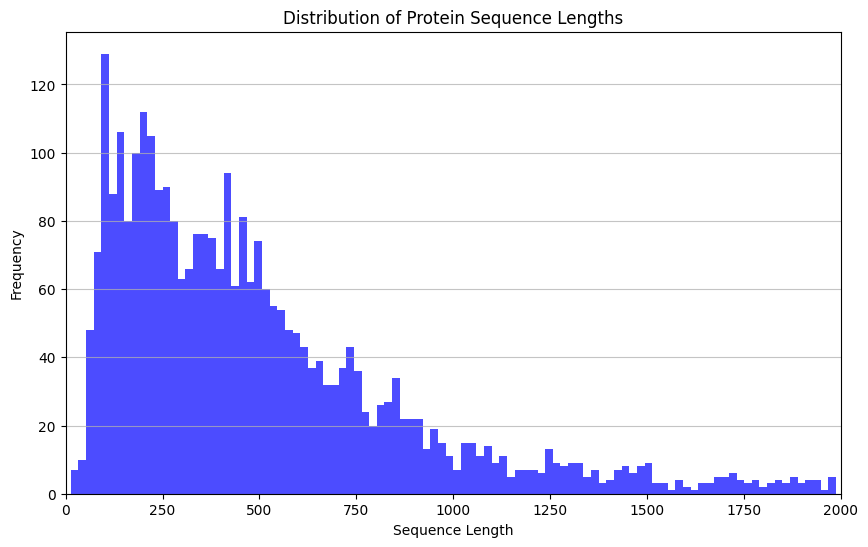

In [5]:
# Basic statistics: Get distribution of protein sequences in the whole dataset
train_lengths = [len(seq) for seq in folds[2]['train']['seq']]
test_lengths = [len(seq) for seq in folds[2]['test']['seq']]
combined_lengths = train_lengths + test_lengths
# Basic statistics: Print summary of sequence length distribution
print(f"Total sequences: {len(combined_lengths)}")
print(f"Average sequence length: {np.mean(combined_lengths):.2f}")
print(f"Median sequence length: {np.median(combined_lengths)}")
print(f"Minimum sequence length: {np.min(combined_lengths)}")
print(f"Maximum sequence length: {np.max(combined_lengths)}")
# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(combined_lengths, bins=100, color='blue', alpha=0.7)
plt.title('Distribution of Protein Sequence Lengths')
plt.xlim(0, 2000)
# plt.xlim(2000, 4000)
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [6]:
# Check query index: 
query_index = 50
print(folds[1]['train']['kw'][query_index])
print(folds[0]['train']['x'][query_index].shape)
print(folds[0]['train']['y'][query_index].shape)

P61244
torch.Size([1, 663])
torch.Size([663])


In [7]:
def build_simple_split(dataframe, seed, train_size=0.85, max_seq_length=2000):
    """
    Builds a dataset and splits it into a single training and testing set.
    
    Args:
        dataframe: Input pandas DataFrame
        seed: Random seed for reproducibility
        train_size: Fraction of data for training (e.g., 0.85 for 85%)
        max_seq_length: Maximum allowed sequence length
        
    Returns:
        dataset: Dictionary with 'train' and 'test' keys
    """
    np.random.seed(seed)
    torch.manual_seed(seed)

    data_all = {'x': [], 'y': [], 'kw': [], 'function': [], 'seq': []}
    disorder_densities = []

    # --- 1. Data Processing (Same as your original logic) ---
    for idx, row in dataframe.iterrows():
        sequence = row['Full_Sequence']
        disorder_labels = row['Consensus']
        
        if pd.isna(sequence) or len(sequence) >= max_seq_length:
            continue
            
        x_tokens = tokenize_input(sequence)
        y_tokens = tokenize_output(disorder_labels)
        
        if len(x_tokens) != len(y_tokens):
            continue
            
        data_all['x'].append(torch.tensor(x_tokens, dtype=torch.long).unsqueeze(0))
        data_all['y'].append(torch.tensor(y_tokens, dtype=torch.long))
        data_all['kw'].append(row['UniProt ACC'])
        data_all['function'].append(row['Protein name'])
        data_all['seq'].append(sequence)
        disorder_densities.append(calculate_disorder_density(y_tokens))

    # --- 2. Stratified Splitting Logic ---
    # Create bins for stratification based on disorder density
    disorder_bins = np.digitize(disorder_densities, bins=[0.2, 0.4, 0.6, 0.8])
    
    # We use StratifiedShuffleSplit for a single random split
    from sklearn.model_selection import StratifiedShuffleSplit
    
    sss = StratifiedShuffleSplit(n_splits=1, train_size=train_size, random_state=seed)
    indices = np.arange(len(data_all['x']))
    
    # sss.split yields only one pair of indices because n_splits=1
    for train_idx, test_idx in sss.split(indices, disorder_bins):
        dataset = {
            'train': {
                'x': [data_all['x'][i] for i in train_idx],
                'y': [data_all['y'][i] for i in train_idx],
                'kw': [data_all['kw'][i] for i in train_idx],
                'function': [data_all['function'][i] for i in train_idx],
                'seq': [data_all['seq'][i] for i in train_idx]
            },
            'test': {
                'x': [data_all['x'][i] for i in test_idx],
                'y': [data_all['y'][i] for i in test_idx],
                'kw': [data_all['kw'][i] for i in test_idx],
                'function': [data_all['function'][i] for i in test_idx],
                'seq': [data_all['seq'][i] for i in test_idx]
            }
        }

    print(f"Total samples: {len(data_all['x'])}")
    print(f"Training set: {len(dataset['train']['x'])} samples ({train_size*100:.1f}%)")
    print(f"Testing set: {len(dataset['test']['x'])} samples ({(1-train_size)*100:.1f}%)")
    
    return dataset

In [8]:
seed_val = 228
# Call the function with 85% train and 15% test
dataset = build_simple_split(disprot_database, seed=seed_val, train_size=0.85)

Total samples: 3027
Training set: 2572 samples (85.0%)
Testing set: 455 samples (15.0%)


In [9]:
# Check query index: 
query_index = 50
print(dataset['train']['kw'][query_index])
print(dataset['train']['x'][query_index].shape)
print(dataset['train']['y'][query_index].shape)


Q0GBY3
torch.Size([1, 297])
torch.Size([297])


### Adjust the target_dilations if you need, [1, 1, 1] mean no dilation

In [10]:
# Load existing model (for prediction - works both for pthes_cv and pthes_cv_tl)
params = get_params('config_idp.ini')
model_tl = DeepDisProt(params, layers=[2,2,2,3,4,4,4,4,4]) # V0
# model_fold = DeepDisProt(params, layers=[2,2,2,3,5,5,5,5,5])
# model_fold = DeepDisProt(params, layers=[2,2,2,3,8,8,8,8,8])
# model_fold = DeepDisProt(params, layers=[2,2,2,3,9,9,9,9,9])

data_version = 'V0'
pth_num = 30
fold_num = 4

# Load checkpoint with proper map_location handling
try:
    # Try loading with weights_only=True first (safer)
    checkpoint = torch.load(f'./Disprot/pthes_cv_tl/{data_version}/fold_{fold_num}/best30.pth', 
                           weights_only=True, map_location=torch.device('cpu'))
    print("✓ Loaded with weights_only=True")
except Exception as e1:
    # Fall back to weights_only=False if the above fails
    print(f"weights_only=True failed: {str(e1)[:100]}...")
    print("Retrying with weights_only=False...")
    checkpoint = torch.load(f'./Disprot/pthes_cv_tl/{data_version}/fold_{fold_num}/{pth_num}.pth', 
                           weights_only=False, map_location=torch.device('cpu'))
    print("✓ Loaded with weights_only=False")

model_tl.load_state_dict(checkpoint, strict=False)
target_dilations = [1, 1, 1]  # Your desired dilation rates
conv_idx = 0

for layer in model_tl.capture_features:
    # Check if the layer is an instance of SmoothConv
    if layer.__class__.__name__ == 'SmoothConv':
        # Get dilation from target list
        d = target_dilations[conv_idx]
        k = layer.conv.kernel_size[0]
        
        # Update dilation rate
        layer.conv.dilation = (d,)
        
        # Crucial: Update padding to maintain sequence length (same as init logic)
        # Formula: padding = (dilation * (kernel_size - 1)) / 2
        layer.conv.padding = ((d * (k - 1)) // 2,)
        
        print(f"SmoothConv {conv_idx} fine-tuned to dilation={d}")
        conv_idx += 1

# Move model to the target device (GPU/CPU)
model_tl.to(device)

print(f"Model configured for prediction, version: {data_version}")
print(f"Model current device: {next(model_tl.parameters()).device}")

✓ Loaded with weights_only=True
SmoothConv 0 fine-tuned to dilation=1
SmoothConv 1 fine-tuned to dilation=1
SmoothConv 2 fine-tuned to dilation=1
Model configured for prediction, version: V0
Model current device: cuda:0


# Cross-validation (weights reset)

In [38]:
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean', smooth_weight=0.1):
        """
        Args:
            alpha: Tensor of weights for each class [w0, w1]
            gamma: Focusing parameter to handle hard examples
            reduction: 'mean' or 'sum'
            smooth_weight: The strength of the smoothing penalty (Total Variation).
                           Higher values lead to smoother, less "jumpy" heatmaps.
        """
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction
        self.smooth_weight = smooth_weight
    
    def forward(self, inputs, targets):
        # inputs shape: (B*L, num_classes) - Logits
        # targets shape: (B*L,) - Labels
        
        # 1. Standard Focal Loss Calculation
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt)**self.gamma * ce_loss
        
        if self.alpha is not None:
            if self.alpha.device != targets.device:
                self.alpha = self.alpha.to(targets.device)
            alpha_t = self.alpha.gather(0, targets.long())
            focal_loss = alpha_t * focal_loss
        
        # 2. Smoothness Penalty (Total Variation)
        # This penalizes large differences between adjacent residues
        tv_loss = 0
        if self.smooth_weight > 0:
            # Convert logits to probabilities
            probs = F.softmax(inputs, dim=-1)
            # Calculate L1 distance between residue i and residue i-1: |P(i) - P(i-1)|
            # This assumes 'inputs' contains residues in their sequential order
            diff = torch.abs(probs[1:] - probs[:-1])
            tv_loss = torch.mean(diff)
            
        # 3. Combine Losses
        if self.reduction == 'mean':
            return torch.mean(focal_loss) + self.smooth_weight * tv_loss
        elif self.reduction == 'sum':
            return torch.sum(focal_loss) + (self.smooth_weight * tv_loss * inputs.size(0))
        else:
            return focal_loss

In [39]:
def get_imbalance_weights(data_all):
    """
    Counts total 0s and 1s across all sequences and calculates alpha.
    """
    # Flatten all labels into one single tensor
    all_labels = torch.cat(data_all['y'])
    
    # Count occurrences
    count_0 = (all_labels == 0).sum().item()
    count_1 = (all_labels == 1).sum().item()
    total = count_0 + count_1
    
    # Calculate inverse frequency weights
    # Formula: total_samples / (num_classes * class_samples)
    alpha_0 = total / (2.0 * count_0)
    alpha_1 = total / (2.0 * count_1)
    
    alpha = torch.tensor([alpha_0, alpha_1], dtype=torch.float)
    
    print(f"--- Class Imbalance Report ---")
    print(f"Class 0 (Ordered): {count_0} ({count_0/total:.2%})")
    print(f"Class 1 (Disordered): {count_1} ({count_1/total:.2%})")
    print(f"Calculated alpha: {alpha}")
    
    return alpha

# 1. Calculate alpha based on your data_all dictionary
alpha_values = get_imbalance_weights(data_all)

--- Class Imbalance Report ---
Class 0 (Ordered): 1199365 (80.34%)
Class 1 (Disordered): 293550 (19.66%)
Calculated alpha: tensor([0.6224, 2.5429])


In [ ]:
manual_alpha = torch.tensor([0.45, 4.5], dtype=torch.float32)

# Move to the same device as your model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
manual_alpha = manual_alpha.to(device)

# Use it in your loss function
loss_func = torch.nn.CrossEntropyLoss(weight=manual_alpha)

print(f"Loss function initialized with manual alpha: {manual_alpha}")

In [40]:
data_version = 'V2'
print(f"Data version: {data_version}")

# Create output directory for logs and models
cv_output_dir = f'./Disprot/pthes_cv/{data_version}'
os.makedirs(cv_output_dir, exist_ok=True)

# Training log file
training_log_csv = os.path.join(cv_output_dir, 'training_log.csv')

# Train model on all 5 folds
for fold_num in range(5):
    print(f"\n{'='*60}")
    print(f"Training Fold {fold_num + 1}/5")
    print(f"{'='*60}")
    
    # Get data for this fold
    fold_data = folds[fold_num]
    
    # Create new model and optimizer for each fold
    params = get_params('config_idp.ini')
    model_fold = DeepDisProt(params, layers=[2,2,2,3,4,4,4,4,4])
    # model_fold = DeepDisProt(params, layers=[2,2,2,3,5,5,5,5,5])
    # model_fold = DeepDisProt(params, layers=[2,2,2,3,8,8,8,8,8])
    # model_fold = DeepDisProt(params, layers=[2,2,2,3,9,9,9,9,9])

    model_fold.to(device)
    optimizer_fold = torch.optim.Adam(model_fold.parameters(), lr=1e-4)

    criterion_fold = FocalLoss(alpha=None, gamma=2.0, reduction='mean')
    # criterion_fold = torch.nn.BCELoss()
    
    # Create trainer for this fold
    fold_output_dir = os.path.join(cv_output_dir, f'fold_{fold_num}')
    os.makedirs(fold_output_dir, exist_ok=True)
    
    exp_fold = TrainModel(
        model=model_fold,
        loss_func=criterion_fold,
        optimizer=optimizer_fold,
        epoch_num=3,
        batch_size=64,
        params_path=fold_output_dir,
        save_span=10000,
        data_train=fold_data['train'],
        data_test=fold_data['test'],
        show_progress=True,
        early_stop_patience=5
    )
    
    #exp_fold._scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_fold, mode='min', factor=0.5, patience=3, verbose=True)

    
    # Train and save logs
    exp_fold.train()
    exp_fold.save_log_csv(fold_num, training_log_csv)
    
    print(f"Fold {fold_num + 1} training complete. Model saved to {fold_output_dir}")

print(f"\nAll folds training complete, logs saved to {training_log_csv}")

Data version: V2

Training Fold 1/5


C:\Users\user\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 0 Train: 2304/2421
Sun Apr 19 15:34:32 2026 Epoch 0: Train Loss: 861.230011, Test Loss: 780.621182, LR: 1.000000e-04
Epoch 1 Train: 2304/2421EarlyStopping counter: 1 out of 5

Sun Apr 19 15:36:59 2026 Epoch 1: Train Loss: 1131.824614, Test Loss: 1703.940854, LR: 1.000000e-04
Epoch 2 Train: 2304/2421EarlyStopping counter: 2 out of 5

Sun Apr 19 15:39:28 2026 Epoch 2: Train Loss: 1990.886159, Test Loss: 2541.153028, LR: 1.000000e-04
Training Done.
Fold 1 training complete. Model saved to ./Disprot/pthes_cv/V2\fold_0

Training Fold 2/5
Epoch 0 Train: 2304/2421
Sun Apr 19 15:41:51 2026 Epoch 0: Train Loss: 2089.946810, Test Loss: 530.207130, LR: 1.000000e-04
Epoch 1 Train: 2304/2421EarlyStopping counter: 1 out of 5

Sun Apr 19 15:44:14 2026 Epoch 1: Train Loss: 1137.943469, Test Loss: 4216.049255, LR: 1.000000e-04
Epoch 2 Train: 2304/2421EarlyStopping counter: 2 out of 5

Sun Apr 19 15:46:38 2026 Epoch 2: Train Loss: 1310.400343, Test Loss: 549.109449, LR: 1.000000e-04
Training Done.

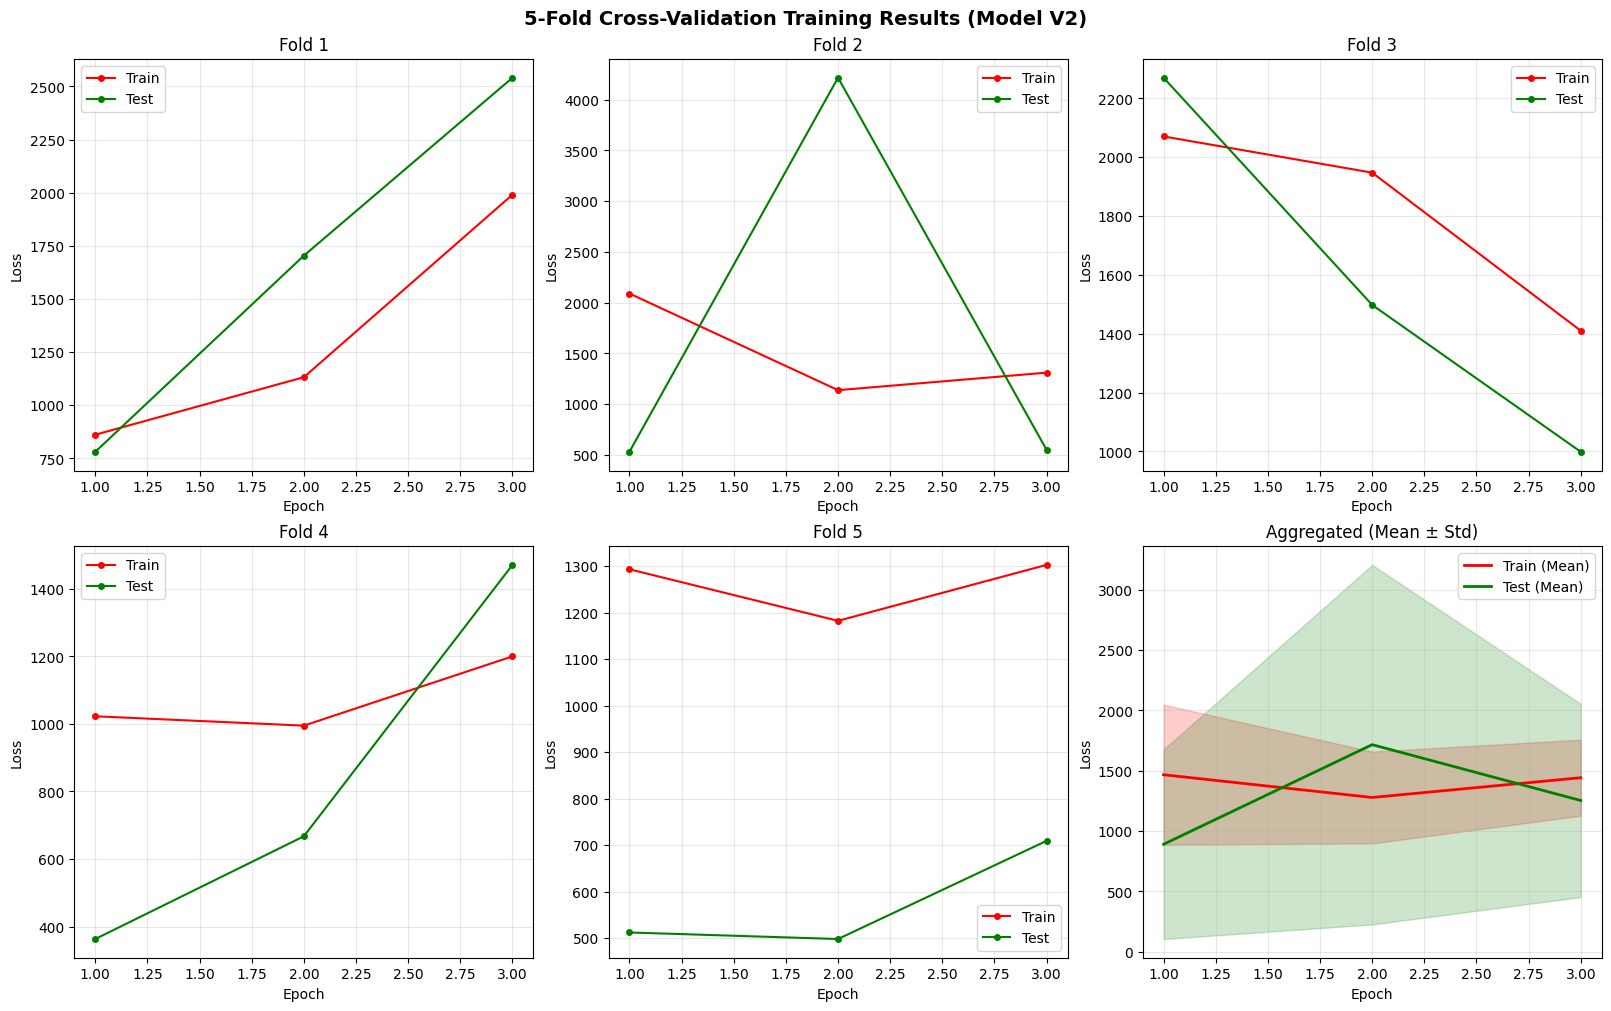


Cross-Validation Summary Statistics

Fold 1:
  Final Train Loss: 1990.886159
  Final Test Loss:  2541.153028
  Best Test Loss:   780.621182 (Epoch 1)

Fold 2:
  Final Train Loss: 1310.400343
  Final Test Loss:  549.109449
  Best Test Loss:   530.207130 (Epoch 1)

Fold 3:
  Final Train Loss: 1410.225414
  Final Test Loss:  998.725378
  Best Test Loss:   998.725378 (Epoch 3)

Fold 4:
  Final Train Loss: 1199.939921
  Final Test Loss:  1470.769697
  Best Test Loss:   363.186175 (Epoch 1)

Fold 5:
  Final Train Loss: 1302.909397
  Final Test Loss:  709.471825
  Best Test Loss:   498.299277 (Epoch 2)

Overall Statistics (Final Test Loss):
  Mean: 1253.845875
  Std:  800.359084
  Min:  549.109449
  Max:  2541.153028


In [41]:
# Load training logs from CSV and plot cross-validation results
import matplotlib.pyplot as plt

data_version = 'V2'
cv_output_dir = f'./Disprot/pthes_cv/{data_version}'

# Load the training log
training_logs_df = pd.read_csv(training_log_csv)

# Create a comprehensive plot showing all folds
fig, axes = plt.subplots(2, 3, figsize=(16, 10), constrained_layout=True)
fig.suptitle(f'5-Fold Cross-Validation Training Results (Model {data_version})', fontsize=14, fontweight='bold')

# Plot individual folds
for fold_num in range(5):
    fold_data = training_logs_df[training_logs_df['fold'] == fold_num]
    
    # Determine subplot position
    row = fold_num // 3
    col = fold_num % 3
    ax = axes[row, col]
    
    ax.plot(fold_data['epoch'], fold_data['train_loss'], 'ro-', label='Train', linewidth=1.5, markersize=4)
    ax.plot(fold_data['epoch'], fold_data['test_loss'], 'go-', label='Test', linewidth=1.5, markersize=4)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'Fold {fold_num + 1}')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Plot aggregated results in the 6th subplot
ax_agg = axes[1, 2]

# Calculate mean and std for each epoch across all folds
epoch_groups = training_logs_df.groupby('epoch')
mean_train_loss = epoch_groups['train_loss'].mean()
std_train_loss = epoch_groups['train_loss'].std()
mean_test_loss = epoch_groups['test_loss'].mean()
std_test_loss = epoch_groups['test_loss'].std()

ax_agg.plot(mean_train_loss.index, mean_train_loss.values, 'r-', label='Train (Mean)', linewidth=2)
ax_agg.fill_between(mean_train_loss.index, 
                     mean_train_loss.values - std_train_loss.values, 
                     mean_train_loss.values + std_train_loss.values, 
                     alpha=0.2, color='r')

ax_agg.plot(mean_test_loss.index, mean_test_loss.values, 'g-', label='Test (Mean)', linewidth=2)
ax_agg.fill_between(mean_test_loss.index, 
                     mean_test_loss.values - std_test_loss.values, 
                     mean_test_loss.values + std_test_loss.values, 
                     alpha=0.2, color='g')

ax_agg.set_xlabel('Epoch')
ax_agg.set_ylabel('Loss')
ax_agg.set_title('Aggregated (Mean ± Std)')
ax_agg.legend()
ax_agg.grid(True, alpha=0.3)

plt.savefig(os.path.join(cv_output_dir, 'cv_loss_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics
print(f"\n{'='*60}")
print("Cross-Validation Summary Statistics")
print(f"{'='*60}")
for fold_num in range(5):
    fold_data = training_logs_df[training_logs_df['fold'] == fold_num]
    final_train_loss = fold_data['train_loss'].iloc[-1]
    final_test_loss = fold_data['test_loss'].iloc[-1]
    best_test_loss = fold_data['test_loss'].min()
    best_epoch = fold_data.loc[fold_data['test_loss'].idxmin(), 'epoch']
    
    print(f"\nFold {fold_num + 1}:")
    print(f"  Final Train Loss: {final_train_loss:.6f}")
    print(f"  Final Test Loss:  {final_test_loss:.6f}")
    print(f"  Best Test Loss:   {best_test_loss:.6f} (Epoch {int(best_epoch)})")

# Calculate overall statistics
final_losses = training_logs_df.groupby('fold')['test_loss'].last()
print(f"\n{'='*60}")
print(f"Overall Statistics (Final Test Loss):")
print(f"  Mean: {final_losses.mean():.6f}")
print(f"  Std:  {final_losses.std():.6f}")
print(f"  Min:  {final_losses.min():.6f}")
print(f"  Max:  {final_losses.max():.6f}")
print(f"{'='*60}")

# Cross-validation (weights not reset)

In [11]:
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean', smooth_weight=0.1):
        """
        Args:
            alpha: Tensor of weights for each class [w0, w1]
            gamma: Focusing parameter to handle hard examples
            reduction: 'mean' or 'sum'
            smooth_weight: The strength of the smoothing penalty (Total Variation).
                           Higher values lead to smoother, less "jumpy" heatmaps.
        """
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction
        self.smooth_weight = smooth_weight
    
    def forward(self, inputs, targets):
        # inputs shape: (B*L, num_classes) - Logits
        # targets shape: (B*L,) - Labels
        
        # 1. Standard Focal Loss Calculation
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt)**self.gamma * ce_loss
        
        if self.alpha is not None:
            if self.alpha.device != targets.device:
                self.alpha = self.alpha.to(targets.device)
            alpha_t = self.alpha.gather(0, targets.long())
            focal_loss = alpha_t * focal_loss
        
        # 2. Smoothness Penalty (Total Variation)
        # This penalizes large differences between adjacent residues
        tv_loss = 0
        if self.smooth_weight > 0:
            # Convert logits to probabilities
            probs = F.softmax(inputs, dim=-1)
            # Calculate L1 distance between residue i and residue i-1: |P(i) - P(i-1)|
            # This assumes 'inputs' contains residues in their sequential order
            diff = torch.abs(probs[1:] - probs[:-1])
            tv_loss = torch.mean(diff)
            
        # 3. Combine Losses
        if self.reduction == 'mean':
            return torch.mean(focal_loss) + self.smooth_weight * tv_loss
        elif self.reduction == 'sum':
            return torch.sum(focal_loss) + (self.smooth_weight * tv_loss * inputs.size(0))
        else:
            return focal_loss

In [12]:
def get_imbalance_weights(data_all):
    """
    Counts total 0s and 1s across all sequences and calculates alpha.
    """
    # Flatten all labels into one single tensor
    all_labels = torch.cat(data_all['y'])
    
    # Count occurrences
    count_0 = (all_labels == 0).sum().item()
    count_1 = (all_labels == 1).sum().item()
    total = count_0 + count_1
    
    # Calculate inverse frequency weights
    # Formula: total_samples / (num_classes * class_samples)
    alpha_0 = total / (2.0 * count_0)
    alpha_1 = total / (2.0 * count_1)
    
    alpha = torch.tensor([alpha_0, alpha_1], dtype=torch.float)
    
    print(f"--- Class Imbalance Report ---")
    print(f"Class 0 (Ordered): {count_0} ({count_0/total:.2%})")
    print(f"Class 1 (Disordered): {count_1} ({count_1/total:.2%})")
    print(f"Calculated alpha: {alpha}")
    
    return alpha

# 1. Calculate alpha based on your data_all dictionary
alpha_values = get_imbalance_weights(data_all)

--- Class Imbalance Report ---
Class 0 (Ordered): 1199365 (80.34%)
Class 1 (Disordered): 293550 (19.66%)
Calculated alpha: tensor([0.6224, 2.5429])


In [14]:
manual_alpha = torch.tensor([0.45, 4.5], dtype=torch.float32)

# Move to the same device as your model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
manual_alpha = manual_alpha.to(device)

# Use it in your loss function
loss_func = torch.nn.CrossEntropyLoss(weight=manual_alpha)

print(f"Loss function initialized with manual alpha: {manual_alpha}")

Loss function initialized with manual alpha: tensor([0.4500, 4.5000], device='cuda:0')


In [16]:
print("\n" + "="*80)
print("TRANSFER LEARNING TRAINING (Weights Carry Over Between Folds)")
print("="*80)

data_version_tl = 'V1'
print(f"Data version: {data_version_tl}")

# Create output directory for transfer learning logs and models
cv_output_dir_tl = f'./Disprot/pthes_cv_tl/{data_version_tl}'
os.makedirs(cv_output_dir_tl, exist_ok=True)
# Training log file for transfer learning
training_log_csv_tl = os.path.join(cv_output_dir_tl, 'training_log_transfer_learning.csv')


TRANSFER LEARNING TRAINING (Weights Carry Over Between Folds)
Data version: V1


In [18]:
data_version_tl = 'V1'
print(f"Data version: {data_version_tl}")

# Create output directory for transfer learning logs and models
cv_output_dir_tl = f'./Disprot/pthes_cv_tl/{data_version_tl}'
os.makedirs(cv_output_dir_tl, exist_ok=True)

# Training log file for transfer learning
training_log_csv_tl = os.path.join(cv_output_dir_tl, 'training_log_transfer_learning.csv')

# 1. Initialize the model and optimizer (outside the Fold loop)
params = get_params('config_idp.ini')

# Your layers [2,2,2,3,4,4,4,4,4] correspond to:
# 3 layers of SmoothConv (dilated), 1 layer of LSmoothConv, and 5 layers of AttnEncoder
model_tl = DeepDisProt(params, layers=[2,2,2,3,4,4,4,4,4])

# 2. Manually execute parameter initialization and move model to device
# (Ensures all layers are properly weighted before training begins)
model_tl.to(device)

Data version: V1


DeepDisProt(
  (embedding): Embedding(24, 256)
  (capture_features): ModuleList(
    (0-2): 3 x SmoothConv(
      (conv): Conv1d(256, 256, kernel_size=(5,), stride=(1,), padding=(2,))
      (ff): PositionWiseFeedForward(
        (fc1): Linear(in_features=256, out_features=768, bias=True)
        (fc2): Linear(in_features=768, out_features=256, bias=True)
        (relu): ReLU()
      )
      (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    )
    (3): LSmoothConv(
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (conv): Conv1d(256, 256, kernel_size=(21,), stride=(1,), padding=(10,))
      (ff): PositionWiseFeedForward(
        (fc1): Linear(in_features=256, out_features=768, bias=True)
        (fc2): Linear(in_features=768, out_features=256, bias=True)
        (relu): ReLU()
      )
    )
    (4-8): 5 x AttnEncoder(
      (attn): AsynAbsoluteAttention(
        (W_q): Linear(in_

In [20]:
# Transfer Learning Approach: Model weights carried from fold to fold
# IMPORTANT: This is NOT standard k-fold cross-validation
# The model is initialized ONCE and continuously trained on each fold, accumulating knowledge

optimizer_tl = torch.optim.Adam(model_tl.parameters(), lr=1e-5)

# 2. Define a persistent Scheduler (does not reset across Folds)
persistent_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_tl, mode='min', factor=0.7, patience=2, verbose=True
)

all_logs_tl = []

# Loop through folds; weights from Fold N will be the starting point for Fold N+1
for fold_num in range(5):
    print(f"\nTraining Fold {fold_num + 1}/5 (Transfer Learning)")
    
    fold_data = folds[fold_num]
    criterion_tl = FocalLoss(alpha=alpha_values.to(device), gamma=2.0, reduction='mean')
    
    fold_output_dir_tl = os.path.join(cv_output_dir_tl, f'fold_{fold_num}')
    os.makedirs(fold_output_dir_tl, exist_ok=True)
    
    # Initialize the Trainer for the current fold
    exp_fold_tl = TrainModel(
        model=model_tl,
        loss_func=criterion_tl,
        optimizer=optimizer_tl,
        epoch_num=3,
        early_stop_patience=3,
        batch_size=64,
        params_path=fold_output_dir_tl,
        save_span=5,
        data_train=fold_data['train'],
        data_test=fold_data['test'],
        show_progress=True
    )
    
    # Overwrite the internal scheduler with the persistent one to maintain LR state
    exp_fold_tl._scheduler = persistent_scheduler
    
    exp_fold_tl.train()
    
    # Store logs including the current Learning Rate (LR)
    fold_log = pd.DataFrame({
        'fold': [fold_num] * len(exp_fold_tl.log['epoch']),
        'epoch': exp_fold_tl.log['epoch'],
        'train_loss': exp_fold_tl.log['train'],
        'test_loss': exp_fold_tl.log['test'],
        'lr': exp_fold_tl.log['lr'] 
    })
    all_logs_tl.append(fold_log)

# Combine all logs
combined_log_df_tl = pd.concat(all_logs_tl, ignore_index=True)
combined_log_df_tl.to_csv(training_log_csv_tl, index=False)

print(f"\nAll folds training complete!")
print(f"Transfer learning logs saved to {training_log_csv_tl}")
print(f"\nFinal model weights accumulated from all folds saved to {cv_output_dir_tl}/fold_4/")

# Display summary
print(f"\n{'='*80}")
print("Transfer Learning Training Summary")
print(f"{'='*80}")
for fold_num in range(5):
    fold_data_tl = combined_log_df_tl[combined_log_df_tl['fold'] == fold_num]
    final_train_loss = fold_data_tl['train_loss'].iloc[-1]
    final_test_loss = fold_data_tl['test_loss'].iloc[-1]
    best_test_loss = fold_data_tl['test_loss'].min()
    best_epoch = fold_data_tl.loc[fold_data_tl['test_loss'].idxmin(), 'epoch']
    
    print(f"\nFold {fold_num + 1}:")
    print(f"  Final Train Loss: {final_train_loss:.6f}")
    print(f"  Final Test Loss:  {final_test_loss:.6f}")
    print(f"  Best Test Loss:   {best_test_loss:.6f} (Epoch {int(best_epoch)})")

print(f"\n{'='*80}")


Training Fold 1/5 (Transfer Learning)


Epoch 0 Train: 2304/2421
Sun Apr 19 14:30:09 2026 Epoch 0: Train Loss: 742.943419, Test Loss: 502.631912, LR: 1.000000e-05
Epoch 1 Train: 2304/2421
Sun Apr 19 14:32:23 2026 Epoch 1: Train Loss: 669.427089, Test Loss: 478.731938, LR: 1.000000e-05
Epoch 2 Train: 2304/2421
Sun Apr 19 14:34:45 2026 Epoch 2: Train Loss: 602.036144, Test Loss: 385.432724, LR: 1.000000e-05


Training Done.

Training Fold 2/5 (Transfer Learning)


Epoch 0 Train: 2304/2421
Sun Apr 19 14:37:13 2026 Epoch 0: Train Loss: 587.358966, Test Loss: 384.716070, LR: 1.000000e-05
Epoch 1 Train: 2304/2421
Sun Apr 19 14:39:48 2026 Epoch 1: Train Loss: 556.937971, Test Loss: 343.039310, LR: 1.000000e-05
Epoch 2 Train: 2304/2421

EarlyStopping counter: 1 out of 3
Training Done.

Training Fold 3/5 (Transfer Learning)


...


Sun Apr 19 14:55:12 2026 Epoch 1: Train Loss: 463.550105, Test Loss: 306.807114, LR: 1.000000e-05
Epoch 2 Train: 2304/2422
Sun Apr 19 14:57:43 2026 Epoch 2: Train Loss: 460.852524, Test Loss: 289.292188, LR: 1.000000e-05


Training Done.

Training Fold 5/5 (Transfer Learning)


Epoch 0 Train: 2304/2422
Sun Apr 19 15:00:34 2026 Epoch 0: Train Loss: 456.913740, Test Loss: 278.584969, LR: 1.000000e-05
Epoch 1 Train: 2304/2422
Sun Apr 19 15:03:11 2026 Epoch 1: Train Loss: 422.252853, Test Loss: 252.355829, LR: 1.000000e-05
Epoch 2 Train: 2304/2422

EarlyStopping counter: 1 out of 3
Training Done.

All folds training complete!
Transfer learning logs saved to ./Disprot/pthes_cv_tl/V1\training_log_transfer_learning.csv

Final model weights accumulated from all folds saved to ./Disprot/pthes_cv_tl/V1/fold_4/

Transfer Learning Training Summary

Fold 1:
  Final Train Loss: 602.036144
  Final Test Loss:  385.432724
  Best Test Loss:   385.432724 (Epoch 3)

Fold 2:
  Final Train Loss: 558.378481
  Final Test Loss:  363.105044
  Best Test Loss:   343.039310 (Epoch 2)

Fold 3:
  Final Train Loss: 498.749929
  Final Test Loss:  313.792322
  Best Test Loss:   313.792322 (Epoch 3)

Fold 4:
  Final Train Loss: 460.852524
  Final Test Loss:  289.292188
  Best Test Loss:   289.292188 (Epoch 3)

Fold 5:
  Final Train Loss: 431.401196
  Final Test Loss:  266.426887
  Best Test Loss:   252.355829 (Epoch 2)




Sun Apr 19 15:05:40 2026 Epoch 2: Train Loss: 431.401196, Test Loss: 266.426887, LR: 1.000000e-05


In [ ]:
print("\n" + "="*80)
print("LONG-TERM FINE-TUNING (Single Fold, 20 Epochs with Early Stopping)")
print("="*80)

# 1. Reconfigure the optimizer, maintaining the fine-tuning learning rate of 1e-5
optimizer_tl = torch.optim.Adam(model_tl.parameters(), lr=1e-5)

# 2. Define Scheduler (Patience 3: Reduce LR if no improvement for 3 epochs)
persistent_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_tl, mode='min', factor=0.5, patience=3, verbose=True
)

# 3. Select a specific Fold for fine-tuning
target_fold = 0
fold_data = folds[target_fold]
print(f"Fine-tuning on Fold {target_fold + 1} for up to 20 Epochs...")

# Set up output directory
ft_output_dir = os.path.join(cv_output_dir_tl, 'fine_tuned_single_fold')
os.makedirs(ft_output_dir, exist_ok=True)

# 4. Instantiate FocalLoss
criterion_tl = FocalLoss(alpha=alpha_values.to(device), gamma=2.0, reduction='mean', smooth_weight=0.0)

# 5. Initialize the Trainer with Early Stopping
exp_ft = TrainModel(
    model=model_tl,
    loss_func=criterion_tl,
    optimizer=optimizer_tl,
    epoch_num=20,           # Maximum 20 Epochs
    batch_size=64,
    params_path=ft_output_dir,
    save_span=5,            # Save checkpoints every 5 epochs
    data_train=fold_data['train'],
    data_test=fold_data['test'],
    show_progress=True,
    early_stop_patience=5   # Stop if Test Loss doesn't improve for 5 epochs
)

# Assign the persistent Scheduler
exp_ft._scheduler = persistent_scheduler

# Start Training
exp_ft.train()

# --- 6. Save final fine-tuned model weights ---
# Using the best_loss recorded by the trainer for the filename
final_model_path = os.path.join(ft_output_dir, 'final_fine_tuned_model.pth')
torch.save({
    'epoch': len(exp_ft.log['epoch']), # Actual number of epochs trained
    'model_state_dict': model_tl.state_dict(),
    'optimizer_state_dict': optimizer_tl.state_dict(),
    'loss': exp_ft.log['test'][-1],
}, final_model_path)

print(f"\nFinal fine-tuned model saved to: {final_model_path}")

# 7. Save logs and plot loss curves
ft_log_csv = os.path.join(ft_output_dir, 'fine_tuning_log.csv')
pd.DataFrame({
    'epoch': exp_ft.log['epoch'],
    'train_loss': exp_ft.log['train'],
    'test_loss': exp_ft.log['test'],
    'lr': exp_ft.log['lr']
}).to_csv(ft_log_csv, index=False)

exp_ft.plot_loss_curve()
print(f"Fine-tuning logs and curves saved in {ft_output_dir}")


Loading and plotting transfer learning results...


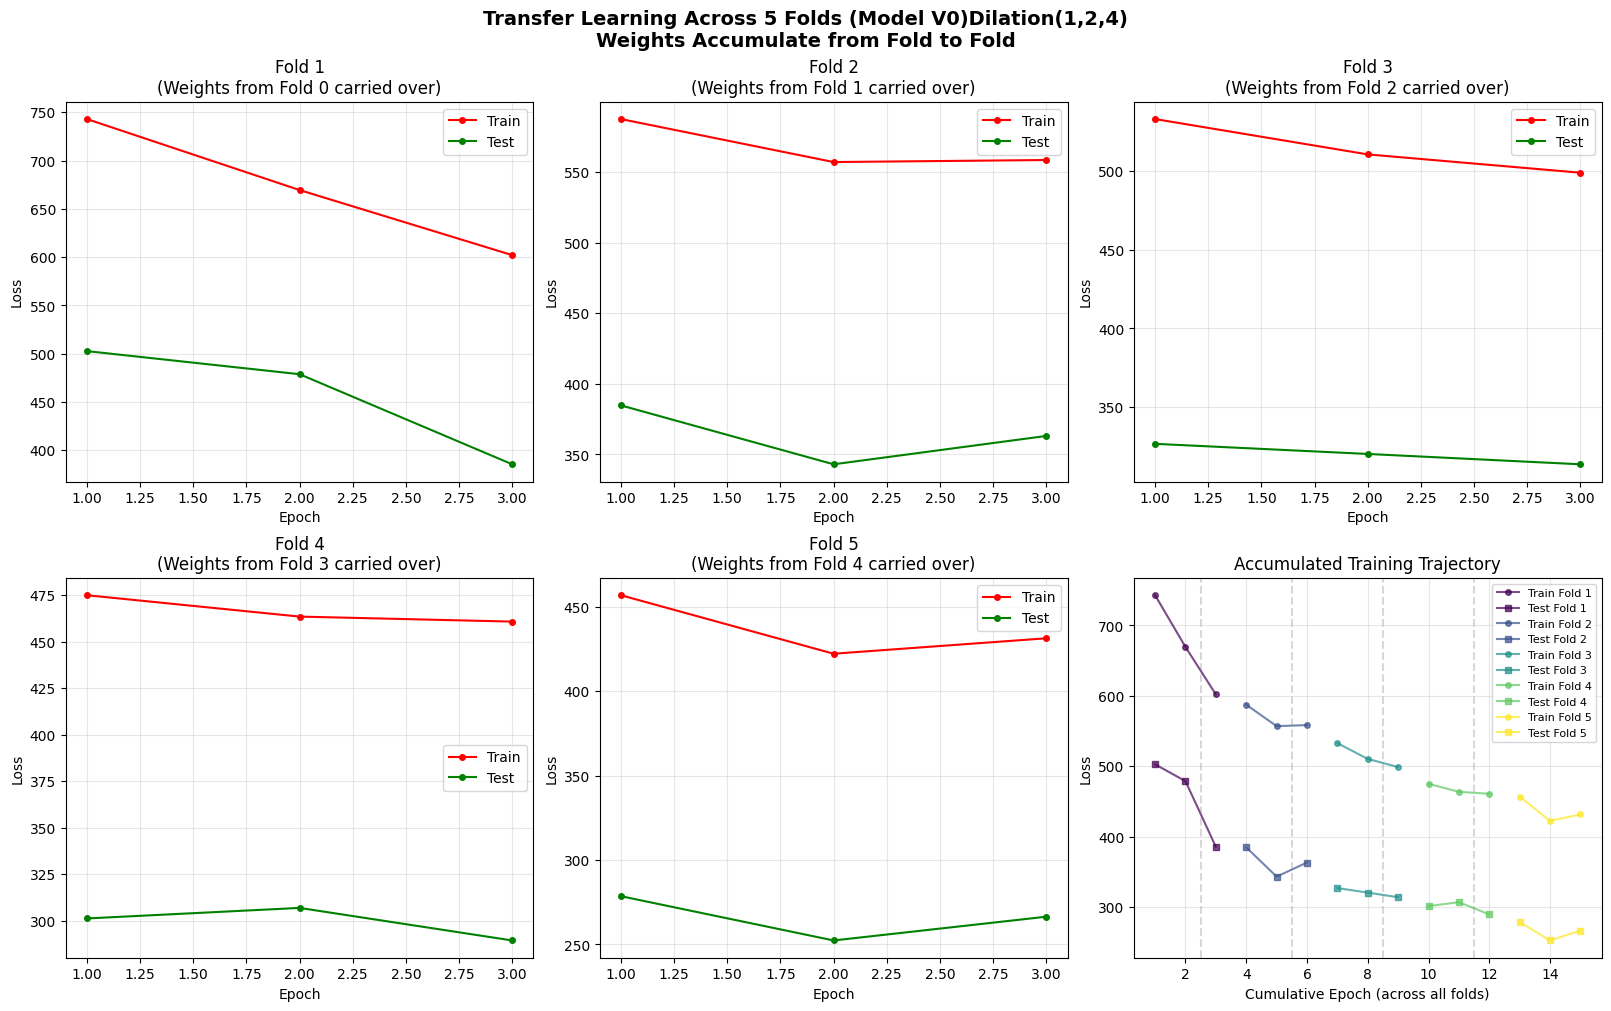


Transfer Learning Summary Statistics

Final Test Loss by Fold:
  Fold 1: 385.432724
  Fold 2: 363.105044
  Fold 3: 313.792322
  Fold 4: 289.292188
  Fold 5: 266.426887

Overall Statistics (Final Test Loss):
  Mean: 323.609833
  Std:  49.814443
  Min:  266.426887
  Max:  385.432724

Key Difference from Standard CV:
  • Weights are NOT reset between folds
  • Model accumulates knowledge across all folds
  • Later folds may have advantage of earlier fold training


In [21]:
# Load and plot transfer learning results
print("\nLoading and plotting transfer learning results...")

data_version_tl = 'V0'
cv_output_dir_tl = f'./Disprot/pthes_cv_tl/{data_version_tl}'

# Load the transfer learning log
training_logs_df_tl = pd.read_csv(training_log_csv_tl)

# Create a comprehensive plot for transfer learning results
fig, axes = plt.subplots(2, 3, figsize=(16, 10), constrained_layout=True)
fig.suptitle(f'Transfer Learning Across 5 Folds (Model {data_version_tl})Dilation(1,2,4)\nWeights Accumulate from Fold to Fold', 
             fontsize=14, fontweight='bold')

# Plot individual folds
for fold_num in range(5):
    fold_data_tl = training_logs_df_tl[training_logs_df_tl['fold'] == fold_num]
    
    # Determine subplot position
    row = fold_num // 3
    col = fold_num % 3
    ax = axes[row, col]
    
    ax.plot(fold_data_tl['epoch'], fold_data_tl['train_loss'], 'ro-', label='Train', linewidth=1.5, markersize=4)
    ax.plot(fold_data_tl['epoch'], fold_data_tl['test_loss'], 'go-', label='Test', linewidth=1.5, markersize=4)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'Fold {fold_num + 1}\n(Weights from Fold {fold_num} carried over)')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Plot accumulated training trajectory in the 6th subplot
ax_accum = axes[1, 2]

# Create a sequential plot showing how loss changes across folds
# Adjust epoch numbers to show progression across folds
epoch_offset = 0
colors_fold = plt.cm.viridis(np.linspace(0, 1, 5))

for fold_num in range(5):
    fold_data_tl = training_logs_df_tl[training_logs_df_tl['fold'] == fold_num]
    epoch_adjusted = fold_data_tl['epoch'] + epoch_offset
    
    ax_accum.plot(epoch_adjusted, fold_data_tl['train_loss'], 'o-', 
                  color=colors_fold[fold_num], label=f'Train Fold {fold_num + 1}', 
                  linewidth=1.5, markersize=4, alpha=0.7)
    ax_accum.plot(epoch_adjusted, fold_data_tl['test_loss'], 's-', 
                  color=colors_fold[fold_num], label=f'Test Fold {fold_num + 1}', 
                  linewidth=1.5, markersize=4, alpha=0.7)
    
    epoch_offset += len(fold_data_tl)
    if fold_num < 4:
        ax_accum.axvline(x=epoch_offset - 0.5, color='gray', linestyle='--', alpha=0.3)

ax_accum.set_xlabel('Cumulative Epoch (across all folds)')
ax_accum.set_ylabel('Loss')
ax_accum.set_title('Accumulated Training Trajectory')
ax_accum.legend(fontsize=8, loc='best')
ax_accum.grid(True, alpha=0.3)

plt.savefig(os.path.join(cv_output_dir_tl, 'transfer_learning_loss_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics comparison
print(f"\n{'='*80}")
print("Transfer Learning Summary Statistics")
print(f"{'='*80}")

final_losses_tl = training_logs_df_tl.groupby('fold')['test_loss'].last()
print(f"\nFinal Test Loss by Fold:")
for fold_num in range(5):
    print(f"  Fold {fold_num + 1}: {final_losses_tl.iloc[fold_num]:.6f}")

print(f"\nOverall Statistics (Final Test Loss):")
print(f"  Mean: {final_losses_tl.mean():.6f}")
print(f"  Std:  {final_losses_tl.std():.6f}")
print(f"  Min:  {final_losses_tl.min():.6f}")
print(f"  Max:  {final_losses_tl.max():.6f}")

print(f"\nKey Difference from Standard CV:")
print(f"  • Weights are NOT reset between folds")
print(f"  • Model accumulates knowledge across all folds")
print(f"  • Later folds may have advantage of earlier fold training")
print(f"{'='*80}")

# Data analysis + visualization of unknown sequences

In [22]:
# Visualization: 1D heatmaps for true vs predicted logits
import matplotlib.pyplot as plt

def visualize_token_predictions(logits, true_labels, seq_id=None, max_classes=2):
    """
    Plot side-by-side 1D heatmaps for predicted class probabilities vs. true labels.
    logits: Tensor of shape [1, L, C] or [L, C]
    true_labels: Tensor of shape [L] with integer class indices.
    max_classes: Number of classes to visualize (defaults to 2 for ordered/disordered)
    Supports any number of classes (2, 3, or more).
    """
    # Ensure 2D [L, C]
    if logits.dim() == 3:
        logits_2d = logits.squeeze(0)  # [L, C]
    else:
        logits_2d = logits

    L_pred = logits_2d.size(0)
    L_true = true_labels.size(0)
    L = min(L_pred, L_true)
    if L_pred != L_true:
        print(f"[WARN] Length mismatch in visualization: pred={L_pred}, true={L_true}. Using first {L} positions.")
    logits_2d = logits_2d[:L]
    true_labels = true_labels[:L]

    # Only use the first max_classes logits (to handle case where model outputs 3 classes but data uses only 2)
    actual_num_classes = logits_2d.size(-1)
    num_classes = min(max_classes, actual_num_classes)
    logits_2d = logits_2d[:, :num_classes]

    # Convert logits to probabilities
    probs = torch.softmax(logits_2d, dim=-1)  # [L, num_classes]

    # Build one-hot for true labels with same [L, num_classes] shape
    true_one_hot = torch.zeros_like(probs)
    idx_range = torch.arange(L, device=true_labels.device)
    true_one_hot[idx_range, true_labels.to(idx_range.device)] = 1.0

    # Prepare for imshow: [num_classes, L]
    probs_np = probs.detach().cpu().numpy().T
    true_np = true_one_hot.detach().cpu().numpy().T

    # Generate class names based on number of classes being visualized
    if num_classes == 3:
        class_names = ['ordered (-)', 'transition (T)', 'disordered (D)']
    elif num_classes == 2:
        class_names = ['ordered (-)', 'disordered (D)']
    else:
        class_names = [f'class {i}' for i in range(num_classes)]

    fig, axes = plt.subplots(1, 2, figsize=(14, 3), sharey=True)

    im0 = axes[0].imshow(probs_np, aspect='auto', cmap='viridis')
    axes[0].set_title('Predicted probabilities')
    axes[0].set_xlabel('Residue index')
    axes[0].set_ylabel('Class')
    axes[0].set_yticks(range(num_classes))
    axes[0].set_yticklabels(class_names)
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(true_np, aspect='auto', cmap='viridis')
    axes[1].set_title('True labels (one-hot)')
    axes[1].set_xlabel('Residue index')
    axes[1].set_yticks(range(num_classes))
    axes[1].set_yticklabels(class_names)
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    if seq_id is not None:
        fig.suptitle(f'Sequence {seq_id}')

    plt.tight_layout()
    plt.show()
print("Visualization dataset function defined")

Visualization dataset function defined


In [25]:
# Load existing model (for prediction - works both for pthes_cv and pthes_cv_tl)
params = get_params('config_idp.ini')
model_tl = DeepDisProt(params, layers=[2,2,2,3,4,4,4,4,4]) # V0
# model_fold = DeepDisProt(params, layers=[2,2,2,3,5,5,5,5,5])
# model_fold = DeepDisProt(params, layers=[2,2,2,3,8,8,8,8,8])
# model_fold = DeepDisProt(params, layers=[2,2,2,3,9,9,9,9,9])

data_version = 'V1'
pth_num = 30
fold_num = 0

# Load checkpoint with proper map_location handling
try:
    # Try loading with weights_only=True first (safer)
    checkpoint = torch.load(f'./Disprot/pthes_cv_tl/{data_version}/fold_{fold_num}/best_model.pth', 
                           weights_only=True, map_location=torch.device('cpu'))
    print("✓ Loaded with weights_only=True")
except Exception as e1:
    # Fall back to weights_only=False if the above fails
    print(f"weights_only=True failed: {str(e1)[:100]}...")
    print("Retrying with weights_only=False...")
    checkpoint = torch.load(f'./Disprot/pthes_cv_tl/{data_version}/fold_{fold_num}/{pth_num}.pth', 
                           weights_only=False, map_location=torch.device('cpu'))
    print("✓ Loaded with weights_only=False")

model_tl.load_state_dict(checkpoint, strict=False)
model_tl.to(device)

✓ Loaded with weights_only=True


DeepDisProt(
  (embedding): Embedding(24, 256)
  (capture_features): ModuleList(
    (0-2): 3 x SmoothConv(
      (conv): Conv1d(256, 256, kernel_size=(5,), stride=(1,), padding=(2,))
      (ff): PositionWiseFeedForward(
        (fc1): Linear(in_features=256, out_features=768, bias=True)
        (fc2): Linear(in_features=768, out_features=256, bias=True)
        (relu): ReLU()
      )
      (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    )
    (3): LSmoothConv(
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (conv): Conv1d(256, 256, kernel_size=(21,), stride=(1,), padding=(10,))
      (ff): PositionWiseFeedForward(
        (fc1): Linear(in_features=256, out_features=768, bias=True)
        (fc2): Linear(in_features=768, out_features=256, bias=True)
        (relu): ReLU()
      )
    )
    (4-8): 5 x AttnEncoder(
      (attn): AsynAbsoluteAttention(
        (W_q): Linear(in_

DIAGNOSTIC: Checking raw dataset labels (before model inference)

Raw dataset label distribution:
  Class 0: 1,199,365 residues
  Class 1: 293,550 residues

Raw labels - Count of 0's: 1,199,365, Count of 1's: 293,550

Processing training data...
  Processed 50/2421 training sequences
  Processed 100/2421 training sequences
  Processed 150/2421 training sequences
  Processed 200/2421 training sequences
  Processed 250/2421 training sequences
  Processed 300/2421 training sequences
  Processed 350/2421 training sequences
  Processed 400/2421 training sequences
  Processed 450/2421 training sequences
  Processed 500/2421 training sequences
  Processed 550/2421 training sequences
  Processed 600/2421 training sequences
  Processed 650/2421 training sequences
  Processed 700/2421 training sequences
  Processed 750/2421 training sequences
  Processed 800/2421 training sequences
  Processed 850/2421 training sequences
  Processed 900/2421 training sequences
  Processed 950/2421 training seque

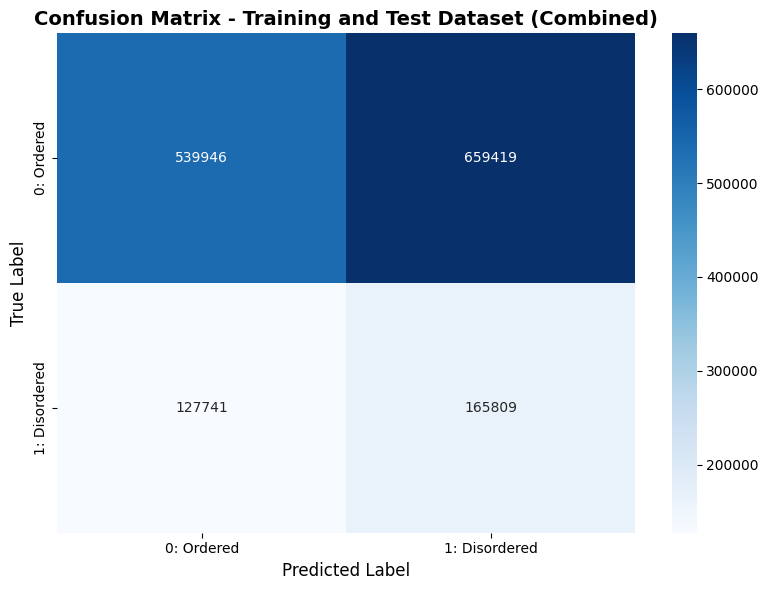


Total sequences evaluated: 1,492,915 residues


In [26]:
# Visualize confusion matrix for whole dataset
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Generate classification report and confusion matrix for the entire training and test dataset
def evaluate_dataset_preds():
    """
    Evaluate the model on the entire training and test dataset combined.
    Generates classification report and confusion matrix aggregated across all sequences.
    Maps disorder labels to binary classification: 0=ordered, 1=disordered
    """
    # DIAGNOSTIC: First, check the raw dataset labels
    print("="*80)
    print("DIAGNOSTIC: Checking raw dataset labels (before model inference)")
    print("="*80)
    
    all_raw_labels = []
    
    total_train = len(folds[0]['train']['x'])
    total_test = len(folds[0]['test']['x'])
    
    # Collect all raw labels
    for i in range(total_train):
        all_raw_labels.extend(folds[0]['train']['y'][i].cpu().numpy().tolist())
    
    for i in range(total_test):
        all_raw_labels.extend(folds[0]['test']['y'][i].cpu().numpy().tolist())
    
    # Count 0's and 1's in raw labels
    all_raw_labels_np = np.array(all_raw_labels)
    unique_raw, counts_raw = np.unique(all_raw_labels_np, return_counts=True)
    
    print(f"\nRaw dataset label distribution:")
    for label, count in zip(unique_raw, counts_raw):
        print(f"  Class {int(label)}: {count:,} residues")
    
    zeros_in_raw = np.sum(all_raw_labels_np == 0)
    ones_in_raw = np.sum(all_raw_labels_np == 1)
    print(f"\nRaw labels - Count of 0's: {zeros_in_raw:,}, Count of 1's: {ones_in_raw:,}")
    
    model_tl.eval()
    all_predictions = []
    all_true_labels = []
    
    #total = total_train + total_test
    total = total_test
    
    
    with torch.no_grad():
        # Process training data
        print("\nProcessing training data...")
        for i in range(total_train):
            input_seq = folds[0]['train']['x'][i].to(device)  # Shape: [1, L]
            true_labels = folds[0]['train']['y'][i]  # Shape: [L]
            
            # Make prediction
            logits = model_tl(input_seq)  # Shape: [1, L, tgt_vocb_size]
            predicted_labels = torch.argmax(logits, dim=-1).squeeze(0)  # Shape: [L]
            
            # Keep predictions as-is to check what the model is outputting
            all_predictions.extend(predicted_labels.cpu().numpy().tolist())
            all_true_labels.extend(true_labels.cpu().numpy().tolist())
            
            if (i + 1) % 50 == 0:
                print(f"  Processed {i + 1}/{total_train} training sequences")
        
        # Process test data
        print("Processing test data...")
        for i in range(total_test):
            input_seq = folds[0]['test']['x'][i].to(device)  # Shape: [1, L]
            true_labels = folds[0]['test']['y'][i]  # Shape: [L]
            
            # Make prediction
            logits = model_tl(input_seq)  # Shape: [1, L, tgt_vocb_size]
            predicted_labels = torch.argmax(logits, dim=-1).squeeze(0)  # Shape: [L]
            
            # Keep predictions as-is to check what the model is outputting
            all_predictions.extend(predicted_labels.cpu().numpy().tolist())
            all_true_labels.extend(true_labels.cpu().numpy().tolist())
            
            if (i + 1) % 50 == 0:
                print(f"  Processed {i + 1}/{total_test} test sequences")
    
    # DIAGNOSTIC: Compare prediction counts with raw label counts
    print("\n" + "="*80)
    print("DIAGNOSTIC: RAW PREDICTION VALUES vs RAW TRUE LABELS")
    print("="*80)
    
    all_predictions_np = np.array(all_predictions)
    all_true_labels_np = np.array(all_true_labels)
    
    # Check the ACTUAL values in predictions (before any conversion)
    unique_pred, counts_pred = np.unique(all_predictions_np, return_counts=True)
    print(f"\nUnique values in model predictions:")
    for label, count in zip(unique_pred, counts_pred):
        print(f"  Class {int(label)}: {count:,} residues")
    
    unique_true, counts_true = np.unique(all_true_labels_np, return_counts=True)
    print(f"\nUnique values in true labels:")
    for label, count in zip(unique_true, counts_true):
        print(f"  Class {int(label)}: {count:,} residues")
    
    zeros_in_pred = np.sum(all_predictions_np == 0)
    ones_in_pred = np.sum(all_predictions_np == 1)
    zeros_in_true = np.sum(all_true_labels_np == 0)
    ones_in_true = np.sum(all_true_labels_np == 1)
    
    print(f"\nModel predictions - Count of 0's: {zeros_in_pred:,}, Count of 1's: {ones_in_pred:,}")
    print(f"True labels      - Count of 0's: {zeros_in_true:,}, Count of 1's: {ones_in_true:,}")
    
    if ones_in_pred == 0 and ones_in_true > 0:
        print("\n⚠️  CRITICAL: Model predicted NO 1's despite true data having 1's!")
        print("  This indicates the logits are NOT being transferred to predictions correctly.")
    elif ones_in_pred == 0:
        print("\n✓ Model correctly has no 1's (matching true labels).")
    
    # Class names
    class_names = ['0: Ordered', '1: Disordered']
    
    # Generate classification report with raw values
    print("\n" + "="*80)
    print("CLASSIFICATION REPORT - RAW PREDICTION VALUES")
    print("="*80)
    print(classification_report(all_true_labels, all_predictions, target_names=class_names, labels=[0, 1], zero_division=0))
    
    # Generate confusion matrix
    cm = confusion_matrix(all_true_labels, all_predictions, labels=[0, 1])
    
    # Plot confusion matrix
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title('Confusion Matrix - Training and Test Dataset (Combined)', fontsize=14, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    print(f"\nTotal sequences evaluated: {len(all_true_labels):,} residues")
    
    return all_predictions, all_true_labels

# Run evaluation
dataset_predictions, dataset_true_labels = evaluate_dataset_preds()

Raw Sequence: MDTKHFLPLDFSTQVNSSLTSPTGRGSMAAPSLHPSLGPGIGSPGQLHSPISTLSSPINGMGPPFSVISSPMGPHSMSVPTTPTLGFSTGSPQLSSPMNPVSSSEDIKPPLGLNGVLKVPAHPSGNMASFTKHICAICGDRSSGKHYGVYSCEGCKGFFKRTVRKDLTYTCRDNKDCLIDKRQRNRCQYCRYQKCLAMGMKREAVQEERQRGKDRNENEVESTSSANEDMPVERILEAELAVEPKTETYVEANMGLNPSSPNDPVTNICQAADKQLFTLVEWAKRIPHFSELPLDDQVILLRAGWNELLIASFSHRSIAVKDGILLATGLHVHRNSAHSAGVGAIFDRVLTELVSKMRDMQMDKTELGCLRAIVLFNPDSKGLSNPAEVEALREKVYASLEAYCKHKYPEQPGRFAKLLLRLPALRSIGLKCLEHLFFFKLIGDTPIDTFLMEMLEAPHQMT
True Labels: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,

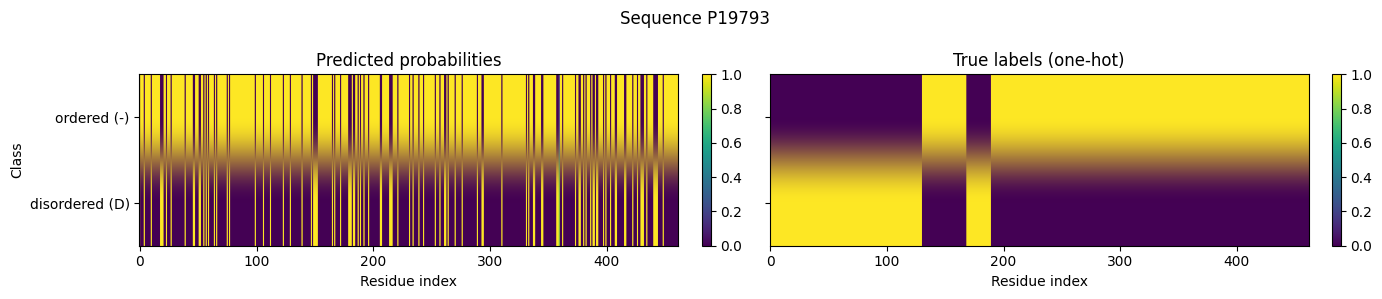

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_tl.to(device) 

# Example of making predictions with the trained model
test_seq_1 = 'MVKTNKPGAKVAVSAQRGSEVTTNTSPQQGHGYVLASSHRSAAVSLNPSHRRSEAAHPTTPHSASDYPRSVSLQSGPGHYAVPTPRGPETGPRTESSRHSSPHLKSQKTQTLASHASSRQWKVSPPREEAARRGSESKSGREVGHHASSIPDAKSTHQLSFQDQKNNLQSQILEDDPPSKVQNPQGVRVPRRILSYPKDEAVQTEPIQRITTTSEIRSPRSPSLLEHGSSCVSADYQTAQRRVPVEESETGPYGPIPSKPKALYRNMNLDSLLKLSVLKDSDGVHRVSARVDPESLHKYSAYPETKPSAKVLVSSQVESNVRTPIRGNSEVGRRVTISPGVQSVEPTHHVTVPSVSEGSHKSSMFVTPEPIYKQQTQKPPEITYMSQGPTPRYPELSQKPSIHAELELTPRPLPPRSLPRYGPDSSWWPLLNPEVETPQSQLTTPDFEPKCSPSLDLLLSGFKIDSSPFCEDLKFQREKASLSPPSPPKEFPSWAPLSEVPQTPKHTCKQPIQRFTAFFLDVSEEMYNRVIWWLKDEEIKRFLEDTTDDGELSKFVKDFSGNASCHPPEAKTWASRPQVPEPRPQAPDLYDDDLEFRPPSRPQSSDNQQYFCAPAPLSPSARPRSPWGKLDPYDSSEDDKEYVGFATLPNQVHRKSVKKGFDFTLMVAGESGLGKSTLVNSLFLTDLYRDRKLLGAEERIMQTVEITKHAVDIEEKGVRLRLTIVDTPGFGDAVNNTECWKPVAEYIDQQFEQYFRDESGLNRKNIQDNRVHCCLYFISPFGHGLRPLDVEFMKALHQRVNIVPILAKADTLTPPEVDHKKRKIREEIEHFGIKIYQFPDCDSDEDEDFKLQDQALKESIPFAVIGSNTVVEARGRRVRGRLYPWGIVEVENPGHCDFVKLRTMLVRTHMQDLKDVTRETHYENYRAQCIQSMTRLVVKERNRNKLTRESGTDFPIPAVPPGTDPETEKLIREKDEELRRMQEMLHKIQKQMKENY'
model_tl.eval()
with torch.no_grad():
    # Get a sample from the test set
    sample_index = 10
    # input_seq = test_lengths
    input_seq = folds[4]['test']['x'][sample_index].to(device)  # Shape: [1, L]
    true_labels = folds[4]['test']['y'][sample_index].to(device)  # Shape: [L]
    kw = folds[4]['test']['kw'][sample_index]
    function = folds[4]['test']['function'][sample_index]
    raw_seq = folds[4]['test']['seq'][sample_index]
    
    # Make prediction
    logits = model_tl(input_seq)  # Shape: [1, L, tgt_vocb_size]
    predicted_labels = torch.argmax(logits, dim=-1).squeeze(0)  # Shape: [L]
    
    # Print results
    print(f"Raw Sequence: {raw_seq}")
    print(f"True Labels: {true_labels.tolist()}")
    print(f"Predicted Labels: {predicted_labels.cpu().tolist()}")
    print(f"Sample ID: {kw}")
    print(f"Function: {function}")
    
    # Visualize true vs predicted logits as 1D heatmaps
    visualize_token_predictions(logits, true_labels, seq_id=kw)

## External Dataset Evaluation with Median Filter Smoothing

Loaded external dataset: 205 proteins
  Processed 50/205 proteins...
  Processed 100/205 proteins...
  Error processing row 120: The size of tensor a (2108) must match the size of tensor b (2000) at non-singleton dimension 1
  Processed 150/205 proteins...
  Error processing row 192: The size of tensor a (2871) must match the size of tensor b (2000) at non-singleton dimension 1
  Processed 200/205 proteins...

Processing complete:
  Successful: 203
  Skipped: 2
  Total residues evaluated: 114,452

EXTERNAL DATASET EVALUATION
                precision    recall  f1-score   support

   Ordered (-)       0.74      0.47      0.58     85100
Disordered (D)       0.26      0.52      0.34     29352

      accuracy                           0.49    114452
     macro avg       0.50      0.50      0.46    114452
  weighted avg       0.62      0.49      0.52    114452



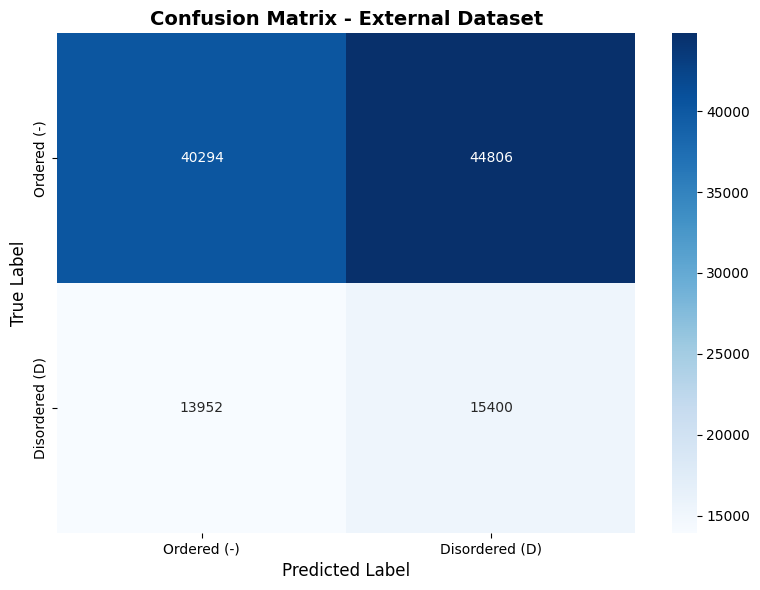


Prediction Statistics:
  True 0's: 85,100
  True 1's: 29,352
  Predicted 0's: 54,246
  Predicted 1's: 60,206


In [28]:
# Import a new dataset and generate classification report + confusion matrix
# Evaluate on external test dataset (unseen data)
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_external_dataset(csv_path, model, device, sequence_col='Sequence', consensus_col='Consensus'):
    """
    Evaluate model on an external dataset with completely unseen proteins.
    
    Args:
        csv_path: Path to CSV file with protein data
        model: Trained PyTorch model
        device: torch device (cuda or cpu)
        sequence_col: Column name for protein sequences
        consensus_col: Column name for consensus disorder labels
    
    Returns:
        predictions, true_labels: Lists of predicted and true binary labels
    """
    
    # Load external dataset
    external_df = pd.read_csv(csv_path)
    print(f"Loaded external dataset: {len(external_df)} proteins")
    
    # Reuse tokenization functions from training
    token_dict = {'A': 1, 'R': 2, 'N': 3, 'D': 4, 'C': 5, 'Q': 6, 'E': 7, 'G': 8, 'H': 9, 'I': 10,
                  'L': 11, 'K': 12, 'M': 13, 'F': 14, 'P': 15, 'O': 16, 'S': 17, 'U': 18, 'T': 19,
                  'W': 20, 'Y': 21, 'V': 22, 'X': 23, '<PAD>': 0}
    label_dict = {'-': 0, 'T': 1, 'D': 1}  # Binary: 0=ordered, 1=disordered/transition
    
    list_of_aa = ['A', 'R', 'N', 'D', 'C', 'Q', 'E', 'G', 'H', 'I', 'L', 'K', 'M', 'F', 'P', 'O', 'S', 'U', 'T', 'W', 'Y', 'V']
    
    def tokenize_sequence(seq):
        """Convert amino acid sequence to token indices"""
        def replace_unknown(aa):
            return aa if aa in list_of_aa else 'X'
        tokens = [token_dict.get(replace_unknown(aa), 0) for aa in seq]
        return tokens
    
    def tokenize_labels(labels):
        """Convert disorder labels to binary (0 or 1)"""
        return [label_dict.get(label, 0) for label in labels]
    
    all_predictions = []
    all_true_labels = []
    skipped_proteins = 0
    
    model_tl.eval()
    
    with torch.no_grad():
        for idx, row in external_df.iterrows():
            try:
                sequence = str(row[sequence_col]).strip()
                consensus = str(row[consensus_col]).strip()
                
                # Skip if missing data or length mismatch
                if len(sequence) == 0 or len(consensus) == 0:
                    skipped_proteins += 1
                    continue
                
                if len(sequence) != len(consensus):
                    print(f"  Skipping row {idx}: sequence-label length mismatch ({len(sequence)} vs {len(consensus)})")
                    skipped_proteins += 1
                    continue
                
                # Tokenize
                x_tokens = tokenize_sequence(sequence)
                y_tokens = tokenize_labels(consensus)
                
                # Convert to tensors
                x_tensor = torch.tensor(x_tokens, dtype=torch.long).unsqueeze(0).to(device)  # [1, L]
                y_tensor = torch.tensor(y_tokens, dtype=torch.long)  # [L]
                
                # Forward pass
                logits = model(x_tensor)  # Shape: [1, L, 3]
                predicted_labels = torch.argmax(logits, dim=-1).squeeze(0)  # Shape: [L]
                
                # Collect predictions and true labels
                all_predictions.extend(predicted_labels.cpu().numpy().tolist())
                all_true_labels.extend(y_tensor.cpu().numpy().tolist())
                
                if (idx + 1) % 50 == 0:
                    print(f"  Processed {idx + 1}/{len(external_df)} proteins...")
            
            except Exception as e:
                print(f"  Error processing row {idx}: {e}")
                skipped_proteins += 1
                continue
    
    print(f"\nProcessing complete:")
    print(f"  Successful: {len(external_df) - skipped_proteins}")
    print(f"  Skipped: {skipped_proteins}")
    print(f"  Total residues evaluated: {len(all_predictions):,}")
    
    return all_predictions, all_true_labels


# Usage: Point this to your external CSV file
external_csv = './Disprot/LLPSDB_processed.csv'  # UPDATE THIS PATH
predictions_ext, labels_ext = evaluate_external_dataset(external_csv, model_tl, device, 
                                                         sequence_col='Sequence', 
                                                         consensus_col='Consensus')

# Generate evaluation metrics
print("\n" + "="*80)
print("EXTERNAL DATASET EVALUATION")
print("="*80)

class_names = ['Ordered (-)', 'Disordered (D)']
print(classification_report(labels_ext, predictions_ext, 
                           target_names=class_names, 
                           labels=[0, 1], 
                           zero_division=0))

# Confusion matrix and visualization
cm_ext = confusion_matrix(labels_ext, predictions_ext, labels=[0, 1])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_ext, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title('Confusion Matrix - External Dataset', fontsize=14, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Print statistics
predictions_np = np.array(predictions_ext)
labels_np = np.array(labels_ext)
print(f"\nPrediction Statistics:")
print(f"  True 0's: {np.sum(labels_np == 0):,}")
print(f"  True 1's: {np.sum(labels_np == 1):,}")
print(f"  Predicted 0's: {np.sum(predictions_np == 0):,}")
print(f"  Predicted 1's: {np.sum(predictions_np == 1):,}")


Loaded external dataset: 205 proteins
  Processed 50/205 proteins (Smoothed)...
  Processed 100/205 proteins (Smoothed)...
  Processed 150/205 proteins (Smoothed)...
  Processed 200/205 proteins (Smoothed)...

Evaluation Complete (Smooth Window Size: 15)

EXTERNAL DATASET EVALUATION (WITH MEDIAN FILTER SMOOTHING)
                precision    recall  f1-score   support

   Ordered (-)       0.75      0.46      0.57     85100
Disordered (D)       0.26      0.55      0.36     29352

      accuracy                           0.49    114452
     macro avg       0.51      0.51      0.46    114452
  weighted avg       0.62      0.49      0.52    114452



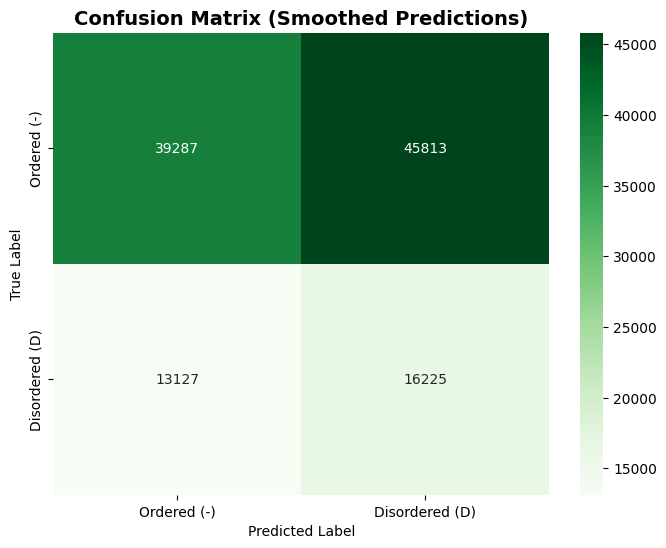


Smoothed Prediction Statistics:
  Predicted 0's (Ordered): 52,414
  Predicted 1's (Disordered): 62,038


In [29]:
from sklearn.metrics import classification_report, confusion_matrix
from scipy.signal import medfilt  # Import median filter
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_external_dataset_smoothed(csv_path, model, device, window_size=11, sequence_col='Sequence', consensus_col='Consensus'):
    """
    Evaluate an external dataset and apply median filter smoothing to predictions.
    
    Args:
        window_size: Size of the smoothing window (must be odd). 
                     Larger values yield smoother results. Suggested: 11, 15, or 21.
    """
    external_df = pd.read_csv(csv_path)
    print(f"Loaded external dataset: {len(external_df)} proteins")
    
    token_dict = {'A': 1, 'R': 2, 'N': 3, 'D': 4, 'C': 5, 'Q': 6, 'E': 7, 'G': 8, 'H': 9, 'I': 10,
                  'L': 11, 'K': 12, 'M': 13, 'F': 14, 'P': 15, 'O': 16, 'S': 17, 'U': 18, 'T': 19,
                  'W': 20, 'Y': 21, 'V': 22, 'X': 23, '<PAD>': 0}
    label_dict = {'-': 0, 'T': 1, 'D': 1}
    list_of_aa = list("ARNDCQEGHILKMFPSTWYV")
    
    all_predictions_smoothed = []
    all_true_labels = []
    skipped_proteins = 0
    
    model.eval()
    
    with torch.no_grad():
        for idx, row in external_df.iterrows():
            try:
                sequence = str(row[sequence_col]).strip()
                consensus = str(row[consensus_col]).strip()
                
                if len(sequence) == 0 or len(consensus) == 0 or len(sequence) != len(consensus):
                    skipped_proteins += 1
                    continue
                
                # Tokenization
                x_tokens = [token_dict.get(aa if aa in list_of_aa else 'X', 0) for aa in sequence]
                y_tokens = [label_dict.get(label, 0) for label in consensus]
                
                x_tensor = torch.tensor(x_tokens, dtype=torch.long).unsqueeze(0).to(device)
                
                # Model Inference
                logits = model(x_tensor)
                raw_preds = torch.argmax(logits, dim=-1).squeeze(0).cpu().numpy()
                
                # --- CRITICAL: Apply Median Filter Smoothing ---
                # Removes flickering and joins fragmented regions
                smoothed_preds = medfilt(raw_preds, kernel_size=window_size).astype(int)
                
                all_predictions_smoothed.extend(smoothed_preds.tolist())
                all_true_labels.extend(y_tokens)
                
                if (idx + 1) % 50 == 0:
                    print(f"  Processed {idx + 1}/{len(external_df)} proteins (Smoothed)...")
            
            except Exception as e:
                skipped_proteins += 1
                continue
                
    print(f"\nEvaluation Complete (Smooth Window Size: {window_size})")
    return all_predictions_smoothed, all_true_labels

# --- Execution ---
external_csv = './Disprot/LLPSDB_processed.csv' 
# Window_size=15 is generally excellent for stabilizing long sequence predictions
predictions_ft, labels_ft = evaluate_external_dataset_smoothed(
    external_csv, model_tl, device, window_size=15
)

# --- Display Results ---
print("\n" + "="*80)
print(f"EXTERNAL DATASET EVALUATION (WITH MEDIAN FILTER SMOOTHING)")
print("="*80)

class_names = ['Ordered (-)', 'Disordered (D)']
print(classification_report(labels_ft, predictions_ft, target_names=class_names, labels=[0, 1]))

# Plotting the Smoothed Confusion Matrix
cm = confusion_matrix(labels_ft, predictions_ft, labels=[0, 1])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Smoothed Predictions)', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# --- Summary Statistics ---
preds_np = np.array(predictions_ft)
print(f"\nSmoothed Prediction Statistics:")
print(f"  Predicted 0's (Ordered): {np.sum(preds_np == 0):,}")
print(f"  Predicted 1's (Disordered): {np.sum(preds_np == 1):,}")

Generating heatmaps for 20 random proteins...


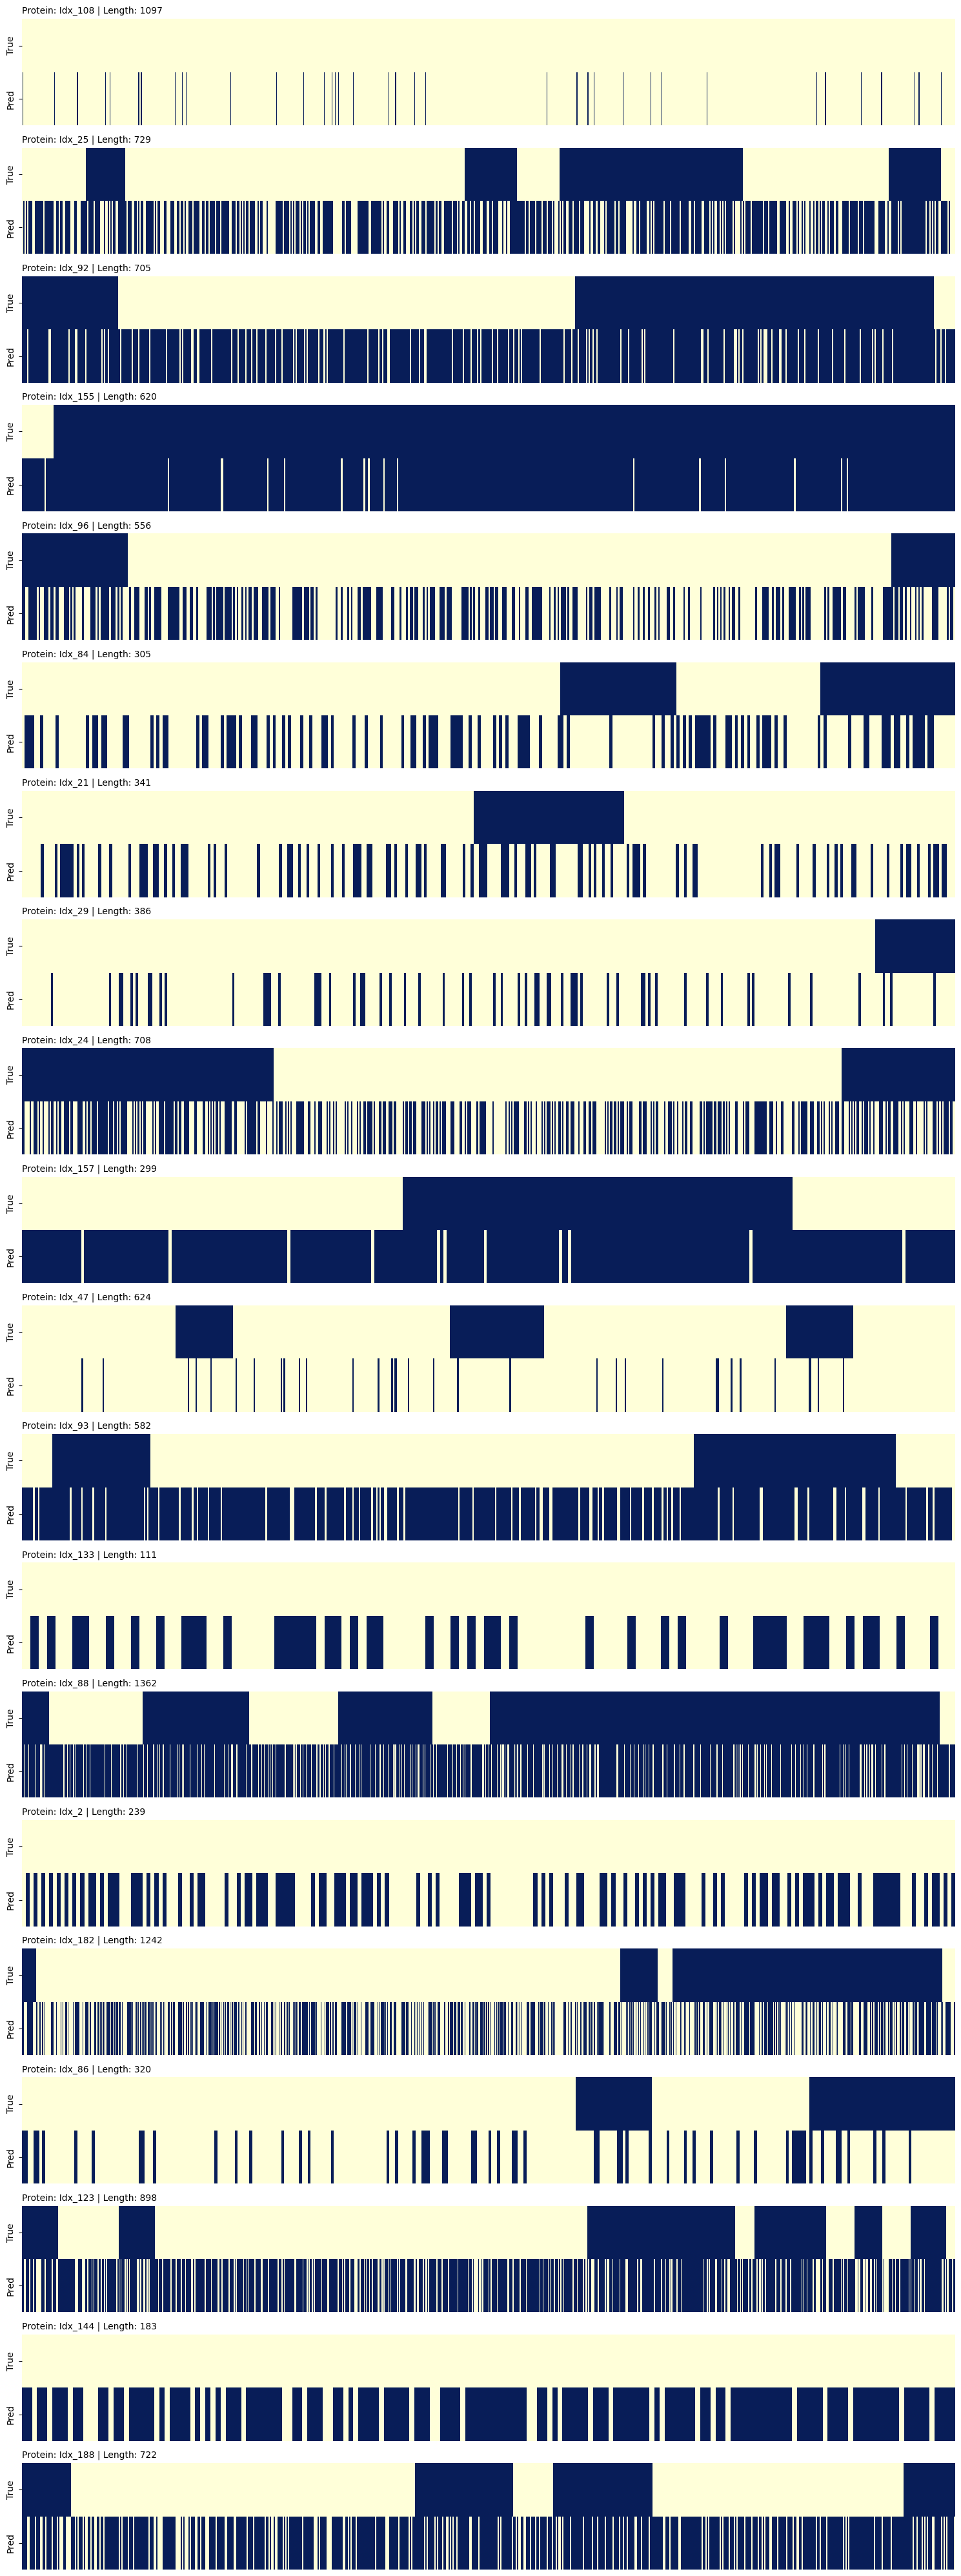

In [30]:
import random
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import numpy as np
import pandas as pd

def plot_random_comparisons(external_df, model, device, num_samples=20):
    """
    Randomly selects num_samples proteins and plots a heatmap comparison 
    between true labels and predicted labels.
    """
    model.eval()
    
    # Ensure the number of samples does not exceed the total available data
    available_indices = external_df.index.tolist()
    sample_indices = random.sample(available_indices, min(num_samples, len(available_indices)))
    
    # Setup subplots
    fig, axes = plt.subplots(num_samples, 1, figsize=(15, 2 * num_samples))
    if num_samples == 1: 
        axes = [axes]
    
    token_dict = {'A': 1, 'R': 2, 'N': 3, 'D': 4, 'C': 5, 'Q': 6, 'E': 7, 'G': 8, 'H': 9, 'I': 10,
                  'L': 11, 'K': 12, 'M': 13, 'F': 14, 'P': 15, 'O': 16, 'S': 17, 'U': 18, 'T': 19,
                  'W': 20, 'Y': 21, 'V': 22, 'X': 23, '<PAD>': 0}
    label_dict = {'-': 0, 'T': 1, 'D': 1}
    
    print(f"Generating heatmaps for {num_samples} random proteins...")

    with torch.no_grad():
        for i, idx in enumerate(sample_indices):
            row = external_df.loc[idx]
            sequence = str(row['Sequence']).strip()
            consensus = str(row['Consensus']).strip()
            
            # Tokenization
            x_tokens = [token_dict.get(aa if aa in 'ARNDCQEGHILKMFPSTWYV' else 'X', 0) for aa in sequence]
            y_true = [label_dict.get(l, 0) for l in consensus]
            
            # Model Inference
            x_tensor = torch.tensor(x_tokens, dtype=torch.long).unsqueeze(0).to(device)
            logits = model(x_tensor)
            
            # Get predictions via argmax
            y_pred = torch.argmax(logits, dim=-1).squeeze(0).cpu().numpy()
            y_true = np.array(y_true)
            
            # Prepare data for heatmap [2, Sequence_Length]
            # Row 0: True Labels, Row 1: Predicted Labels
            heatmap_data = np.vstack([y_true, y_pred])
            
            # Draw individual heatmap
            sns.heatmap(heatmap_data, cmap="YlGnBu", cbar=False, ax=axes[i], 
                        xticklabels=False, yticklabels=['True', 'Pred'])
            
            # Annotate with Protein ID and Sequence Length
            seq_id = row.get('Entry Name', row.get('kw', f'Idx_{idx}'))
            axes[i].set_title(f"Protein: {seq_id} | Length: {len(sequence)}", loc='left', fontsize=10)

    plt.tight_layout()
    plt.show()

# --- Usage ---
# Ensure external_df is loaded (e.g., from LLPSDB_processed.csv)
external_df = pd.read_csv(external_csv)
plot_random_comparisons(external_df, model_tl, device, num_samples=20)

Generating smoothed heatmaps for 20 proteins (Window Size: 15)...


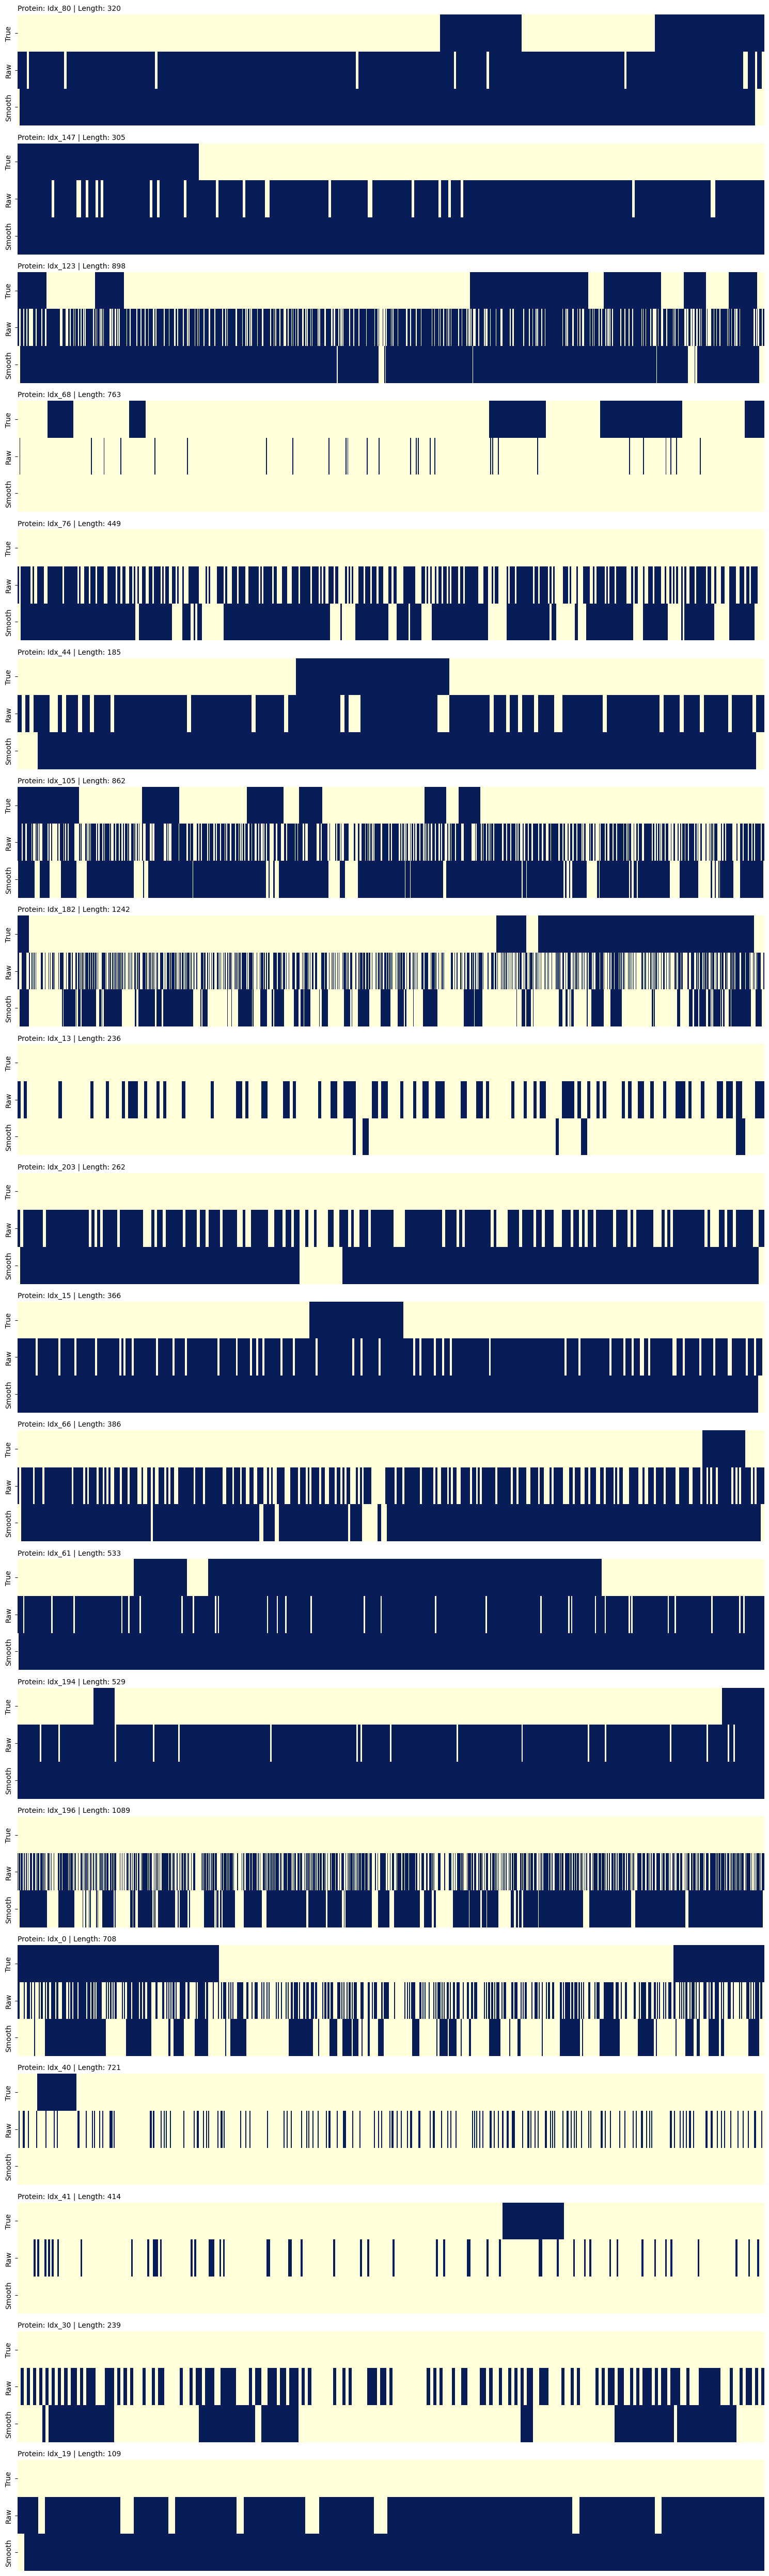

In [31]:
import random
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import medfilt  # Import median filter for post-processing

def plot_random_comparisons_smoothed(external_df, model, device, num_samples=20, window_size=15):
    """
    Randomly selects protein samples and plots a heatmap comparing 
    True labels vs. Raw predictions vs. Smoothed predictions.
    """
    model.eval()
    available_indices = external_df.index.tolist()
    sample_indices = random.sample(available_indices, min(num_samples, len(available_indices)))
    
    # Setup subplots: each protein now has 3 rows (True, Raw, Smooth)
    fig, axes = plt.subplots(num_samples, 1, figsize=(15, 2.5 * num_samples))
    if num_samples == 1: 
        axes = [axes]
    
    token_dict = {'A': 1, 'R': 2, 'N': 3, 'D': 4, 'C': 5, 'Q': 6, 'E': 7, 'G': 8, 'H': 9, 'I': 10,
                  'L': 11, 'K': 12, 'M': 13, 'F': 14, 'P': 15, 'O': 16, 'S': 17, 'U': 18, 'T': 19,
                  'W': 20, 'Y': 21, 'V': 22, 'X': 23, '<PAD>': 0}
    label_dict = {'-': 0, 'T': 1, 'D': 1}
    
    print(f"Generating smoothed heatmaps for {num_samples} proteins (Window Size: {window_size})...")

    with torch.no_grad():
        for i, idx in enumerate(sample_indices):
            row = external_df.loc[idx]
            sequence = str(row['Sequence']).strip()
            consensus = str(row['Consensus']).strip()
            
            # Tokenization
            x_tokens = [token_dict.get(aa if aa in 'ARNDCQEGHILKMFPSTWYV' else 'X', 0) for aa in sequence]
            y_true = np.array([label_dict.get(l, 0) for l in consensus])
            
            # Model raw prediction
            x_tensor = torch.tensor(x_tokens, dtype=torch.long).unsqueeze(0).to(device)
            logits = model(x_tensor)
            y_pred_raw = torch.argmax(logits, dim=-1).squeeze(0).cpu().numpy()
            
            # --- CRITICAL: Post-processing Smoothing ---
            y_pred_smooth = medfilt(y_pred_raw, kernel_size=window_size).astype(int)
            
            # Prepare heatmap data: True (top), Raw (middle), Smoothed (bottom)
            heatmap_data = np.vstack([y_true, y_pred_raw, y_pred_smooth])
            
            # Draw heatmap
            sns.heatmap(heatmap_data, cmap="YlGnBu", cbar=False, ax=axes[i], 
                        xticklabels=False, yticklabels=['True', 'Raw', 'Smooth'])
            
            # Annotation info
            seq_id = row.get('Entry Name', row.get('kw', f'Idx_{idx}'))
            axes[i].set_title(f"Protein: {seq_id} | Length: {len(sequence)}", loc='left', fontsize=10)

    plt.tight_layout()
    plt.show()

# --- Usage ---
# external_df should be pre-loaded from your CSV path
external_df = pd.read_csv(external_csv)
# Setting window_size to 11 or 15 effectively eliminates "vertical noise" in the heatmaps
plot_random_comparisons_smoothed(external_df, model_tl, device, num_samples=20, window_size=15)

In [ ]:
#!pip install sklearn-crfsuite

## CRF Post-Processing for Sequence Prediction Smoothing

In [32]:
import sklearn_crfsuite
from sklearn_crfsuite import scorers
from sklearn_crfsuite import metrics

def train_crf_post_processor(true_labels_list, raw_preds_list):
    """
    Train a CRF (Conditional Random Field) using training set predictions 
    to learn how to fix model errors and optimize transition logic.
    
    true_labels_list: List of ground truth labels for each sequence [0, 1, 1, ...]
    raw_preds_list: List of raw model outputs for each sequence [0, 1, 0, ...]
    """
    
    # Convert data to CRF format: each residue is represented as a feature dictionary
    def sent2features(preds):
        return [{'pred': str(p)} for p in preds]
    
    X_train = [sent2features(p) for p in raw_preds_list]
    y_train = [[str(l) for l in labels] for labels in true_labels_list]
    
    # Initialize and train the CRF model
    crf = sklearn_crfsuite.CRF(
        algorithm='lbfgs',
        c1=0.1,
        c2=0.1,
        max_iterations=100,
        all_possible_transitions=True
    )
    crf.fit(X_train, y_train)
    return crf

def apply_crf_smoothing(crf, raw_preds):
    """
    Apply the trained CRF to a single sequence prediction.
    """
    features = [{'pred': str(p)} for p in raw_preds]
    # crf.predict returns a list of strings; convert back to integers
    prediction = crf.predict([features])[0]
    return [int(p) for p in prediction]

# --- Core logic integration for evaluation ---
def evaluate_with_crf(external_df, model, crf_model, device):
    all_preds_crf = []
    
    model.eval()
    with torch.no_grad():
        for idx, row in external_df.iterrows():
            # ... standard model inference ...
            logits = model(x_tensor)
            raw_preds = torch.argmax(logits, dim=-1).squeeze(0).cpu().numpy().tolist()
            
            # --- Applying CRF Smoothing ---
            # CRF determines the most probable sequence path based on 
            # current predictions and neighboring transition probabilities.
            smoothed_preds = apply_crf_smoothing(crf_model, raw_preds)
            
            all_preds_crf.extend(smoothed_preds)
            # ... 
    return all_preds_crf

In [33]:
# Collect validation set predictions to train the CRF post-processor
raw_preds_for_crf = []
true_labels_for_crf = []

model_tl.eval()
with torch.no_grad():
    # Use the test set from the final Fold (Fold 4) as the learning data for CRF
    for x_tensor, y_tensor in zip(folds[4]['test']['x'], folds[4]['test']['y']):
        x_tensor = x_tensor.to(device)
        logits = model_tl(x_tensor)
        
        # Get the raw model predictions
        raw_pred = torch.argmax(logits, dim=-1).squeeze(0).cpu().numpy().tolist()
        
        raw_preds_for_crf.append(raw_pred)
        true_labels_for_crf.append(y_tensor.tolist())

# Train the CRF model
crf_post_processor = train_crf_post_processor(true_labels_for_crf, raw_preds_for_crf)
print("CRF Post-Processor training complete!")

CRF Post-Processor training complete!


Loaded external dataset: 205 proteins
  Processed 100/205 proteins...
  Processed 200/205 proteins...

Evaluation Finished:
  Total Cropped (>2000): 2
  Total Skipped: 0
  Total Residues: 118,452

FINAL EVALUATION REPORT (CRF SMOOTHED)
                precision    recall  f1-score   support

   Ordered (-)       0.75      1.00      0.86     89009
Disordered (D)       0.00      0.00      0.00     29443

      accuracy                           0.75    118452
     macro avg       0.38      0.50      0.43    118452
  weighted avg       0.56      0.75      0.64    118452



C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


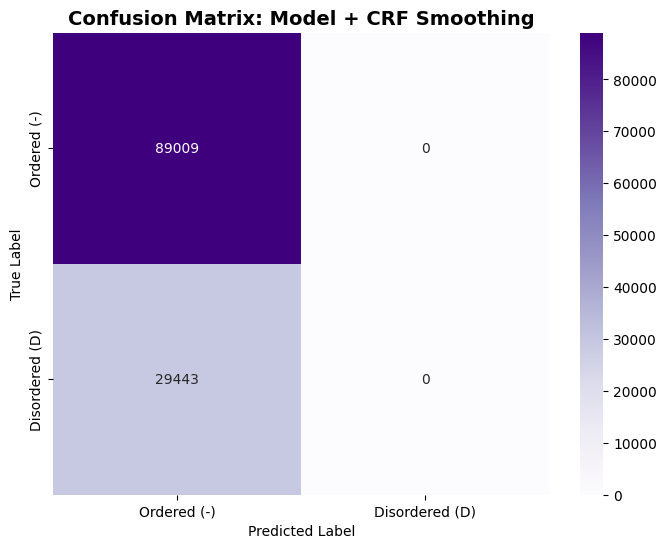

In [34]:
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_external_with_crf(csv_path, model, crf_model, device):
    """
    Evaluate the external dataset using the trained CRF model for prediction smoothing,
    including automatic handling of ultra-long sequences.
    """
    external_df = pd.read_csv(csv_path)
    print(f"Loaded external dataset: {len(external_df)} proteins")
    
    # Basic dictionary definitions
    token_dict = {'A': 1, 'R': 2, 'N': 3, 'D': 4, 'C': 5, 'Q': 6, 'E': 7, 'G': 8, 'H': 9, 'I': 10,
                  'L': 11, 'K': 12, 'M': 13, 'F': 14, 'P': 15, 'O': 16, 'S': 17, 'U': 18, 'T': 19,
                  'W': 20, 'Y': 21, 'V': 22, 'X': 23, '<PAD>': 0}
    label_dict = {'-': 0, 'T': 1, 'D': 1}
    list_of_aa = list("ARNDCQEGHILKMFPSTWYV")
    
    # Model hard limit (Positional Encoding length limit)
    MAX_LEN = 2000 
    
    all_true_labels = []
    all_crf_predictions = []
    skipped_count = 0
    cropped_count = 0

    model.eval()
    with torch.no_grad():
        for idx, row in external_df.iterrows():
            try:
                sequence = str(row['Sequence']).strip()
                consensus = str(row['Consensus']).strip()
                
                # 1. Handle ultra-long sequences (prevents Positional Encoding overflow)
                if len(sequence) > MAX_LEN:
                    sequence = sequence[:MAX_LEN]
                    consensus = consensus[:MAX_LEN]
                    cropped_count += 1
                
                if len(sequence) == 0 or len(consensus) == 0:
                    skipped_count += 1
                    continue
                
                # 2. Tokenization
                x_tokens = [token_dict.get(aa if aa in list_of_aa else 'X', 0) for aa in sequence]
                y_true = [label_dict.get(l, 0) for l in consensus]
                
                x_tensor = torch.tensor(x_tokens, dtype=torch.long).unsqueeze(0).to(device)
                
                # 3. Model raw inference
                logits = model(x_tensor)
                raw_preds = torch.argmax(logits, dim=-1).squeeze(0).cpu().numpy().tolist()
                
                # 4. CRF Post-processing smoothing
                # apply_crf_smoothing returns the sequence path predicted by CRF
                smoothed_preds = apply_crf_smoothing(crf_model, raw_preds)
                
                # 5. Convert to binary classification (0=Ordered, 1=Disordered)
                # Assumes model output 0 is Ordered, while 1 and 2 are Disorder-related
                y_pred_binary = [1 if p > 0 else 0 for p in smoothed_preds]
                
                all_crf_predictions.extend(y_pred_binary)
                all_true_labels.extend(y_true)
                
                if (idx + 1) % 100 == 0:
                    print(f"  Processed {idx + 1}/{len(external_df)} proteins...")
                    
            except Exception as e:
                print(f"  Error at row {idx}: {e}")
                skipped_count += 1
                continue

    print(f"\nEvaluation Finished:")
    print(f"  Total Cropped (>2000): {cropped_count}")
    print(f"  Total Skipped: {skipped_count}")
    print(f"  Total Residues: {len(all_true_labels):,}")
    
    return all_true_labels, all_crf_predictions

# --- Execute Evaluation ---
# Ensure crf_post_processor has been trained previously
true_labels, crf_preds = evaluate_external_with_crf(
    './Disprot/LLPSDB_processed.csv', 
    model_tl, 
    crf_post_processor, 
    device
)

# --- Generate Metrics Report and Confusion Matrix ---
print("\n" + "="*50)
print("FINAL EVALUATION REPORT (CRF SMOOTHED)")
print("="*50)

target_names = ['Ordered (-)', 'Disordered (D)']
print(classification_report(true_labels, crf_preds, target_names=target_names))

cm = confusion_matrix(true_labels, crf_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix: Model + CRF Smoothing', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Generating heatmaps for 5 random proteins with CRF Smoothing...


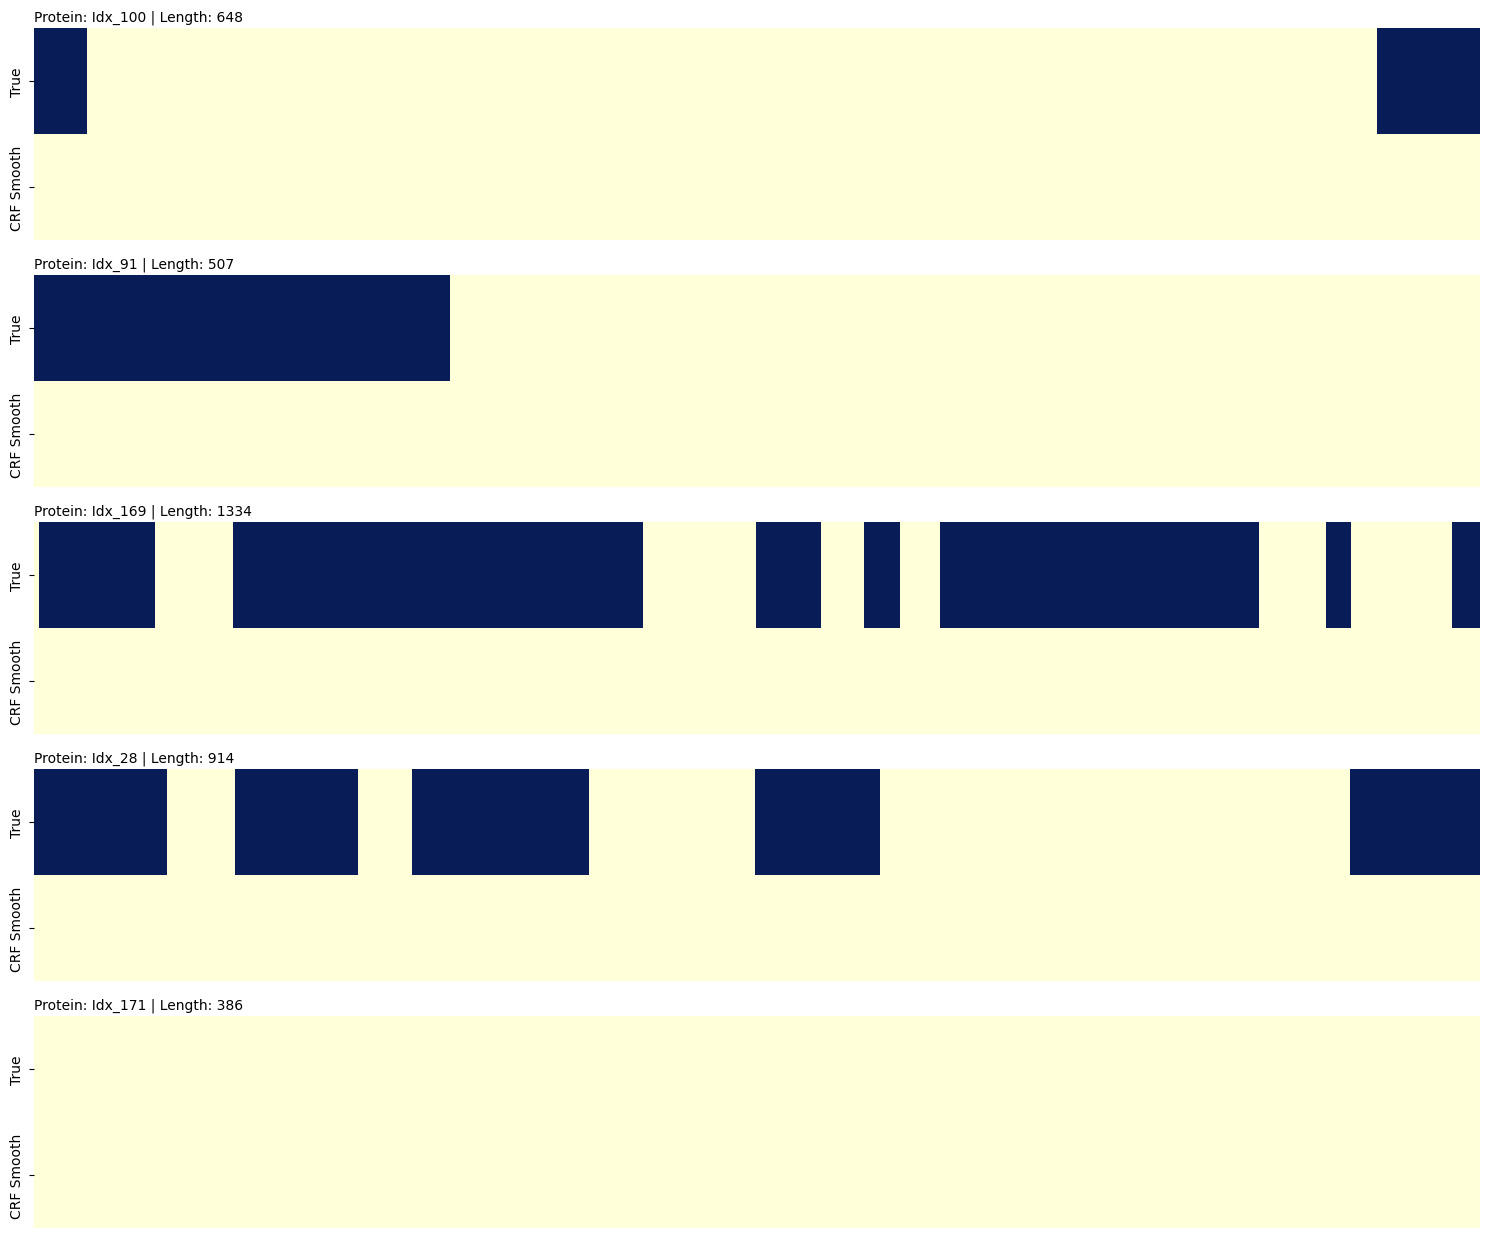

In [35]:
import random
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_random_crf_comparisons(csv_path, model, crf_model, device, num_samples=5):
    """
    Randomly selects num_samples proteins and plots a heatmap comparing 
    Ground Truth labels against CRF-smoothed predictions.
    """
    external_df = pd.read_csv(csv_path)
    available_indices = external_df.index.tolist()
    
    # Random sampling
    sample_indices = random.sample(available_indices, min(num_samples, len(available_indices)))
    
    # Configuration
    token_dict = {'A': 1, 'R': 2, 'N': 3, 'D': 4, 'C': 5, 'Q': 6, 'E': 7, 'G': 8, 'H': 9, 'I': 10,
                  'L': 11, 'K': 12, 'M': 13, 'F': 14, 'P': 15, 'O': 16, 'S': 17, 'U': 18, 'T': 19,
                  'W': 20, 'Y': 21, 'V': 22, 'X': 23, '<PAD>': 0}
    label_dict = {'-': 0, 'T': 1, 'D': 1}
    MAX_LEN = 2000
    
    fig, axes = plt.subplots(num_samples, 1, figsize=(15, 2.5 * num_samples))
    if num_samples == 1: 
        axes = [axes]

    model.eval()
    print(f"Generating heatmaps for {num_samples} random proteins with CRF Smoothing...")

    with torch.no_grad():
        for i, idx in enumerate(sample_indices):
            row = external_df.loc[idx]
            sequence = str(row['Sequence']).strip()
            consensus = str(row['Consensus']).strip()
            
            # Handle sequence length limit (crop if necessary)
            if len(sequence) > MAX_LEN:
                sequence = sequence[:MAX_LEN]
                consensus = consensus[:MAX_LEN]

            # Tokenization
            x_tokens = [token_dict.get(aa if aa in "ARNDCQEGHILKMFPSTWYV" else 'X', 0) for aa in sequence]
            y_true = np.array([label_dict.get(l, 0) for l in consensus])
            
            # Model inference
            x_tensor = torch.tensor(x_tokens, dtype=torch.long).unsqueeze(0).to(device)
            logits = model(x_tensor)
            raw_preds = torch.argmax(logits, dim=-1).squeeze(0).cpu().numpy().tolist()
            
            # Apply CRF Smoothing
            smoothed_preds = apply_crf_smoothing(crf_model, raw_preds)
            y_pred_crf = np.array([1 if p > 0 else 0 for p in smoothed_preds])
            
            # Prepare heatmap data [2, Length]
            heatmap_data = np.vstack([y_true, y_pred_crf])
            
            # Plotting
            sns.heatmap(heatmap_data, cmap="YlGnBu", cbar=False, ax=axes[i], 
                        xticklabels=False, yticklabels=['True', 'CRF Smooth'])
            
            # Annotations
            seq_id = row.get('Entry Name', row.get('kw', f'Idx_{idx}'))
            axes[i].set_title(f"Protein: {seq_id} | Length: {len(sequence)}", loc='left', fontsize=10)

    plt.tight_layout()
    plt.show()

# --- Execution ---
plot_random_crf_comparisons('./Disprot/LLPSDB_processed.csv', model_tl, crf_post_processor, device, num_samples=5)

In [36]:
print(model_tl)

DeepDisProt(
  (embedding): Embedding(24, 256)
  (capture_features): ModuleList(
    (0-2): 3 x SmoothConv(
      (conv): Conv1d(256, 256, kernel_size=(5,), stride=(1,), padding=(2,))
      (ff): PositionWiseFeedForward(
        (fc1): Linear(in_features=256, out_features=768, bias=True)
        (fc2): Linear(in_features=768, out_features=256, bias=True)
        (relu): ReLU()
      )
      (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    )
    (3): LSmoothConv(
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (conv): Conv1d(256, 256, kernel_size=(21,), stride=(1,), padding=(10,))
      (ff): PositionWiseFeedForward(
        (fc1): Linear(in_features=256, out_features=768, bias=True)
        (fc2): Linear(in_features=768, out_features=256, bias=True)
        (relu): ReLU()
      )
    )
    (4-8): 5 x AttnEncoder(
      (attn): AsynAbsoluteAttention(
        (W_q): Linear(in_